# Análisis de errores por slices, Plan de mitigación y Mapas comparativos

El **plan de mitigación de errores** consta de dos fases:

- **Diagnóstico**: análisis de errores por **slices** (subpoblaciones) sobre las predicciones OOF del campeón del Sprint 3, con un embudo estadístico de 3 etapas (elegibilidad → IC 95 % < F2 global → Bonferroni).
- **Fase A — estrategias candidatas**: se evalúan de forma independiente cuatro estrategias de mitigación (A1 stacking, A2 re-inclusión de features, A3 umbral por slice, **A4 ensemble de semillas**), cada una contra el mismo baseline y con criterio de aceptación por **bootstrap pareado** (p < 0.05).
- **Fase B — combinación forward incremental**: las estrategias aceptadas se combinan de forma forward, verificando que cada adición aporte mejora significativa.
- **Evaluación final**: el modelo resultante se aplica **una sola vez** al hold-out, con IC 95 % y contraste contra umbrales de la matriz de objetivos.
- **Mapas comparativos**: (1) isovalores de Au (anomalías cortas) vs. (2) probabilidades del modelo (halo extendido = zonas de interés para muestreo dirigido).

**Métrica de decisión: F2-Score** (β = 2); Recall principal, Precision restricción. Todas las demás métricas se reportan pero no deciden.

## Configuración

In [1]:
import warnings, os, json, time, joblib, platform
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from scipy.interpolate import griddata

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (fbeta_score, make_scorer, f1_score, precision_score,
                             recall_score, accuracy_score, roc_auc_score,
                             average_precision_score, brier_score_loss,
                             confusion_matrix, precision_recall_curve, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTETomek

import xgboost as xgb

SEED = 42
np.random.seed(SEED)
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
F2_SCORER = make_scorer(fbeta_score, beta=2)

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150,
                     'font.size': 11, 'axes.titlesize': 13})

def coral(val, vmin=0, vmax=1, cmap='RdYlGn'):
    """Color condicional para tablas estilizadas."""
    cm = plt.get_cmap(cmap)
    norm = max(min((val - vmin) / max(vmax - vmin, 1e-9), 1), 0)
    r, g, b, _ = cm(norm)
    return f'background-color: rgba({int(r*255)},{int(g*255)},{int(b*255)},0.45)'

# ── Directorios de salida ──
OUT = 'outputs_sprint4'
DIR_DATA = f'{OUT}/data'
DIR_MOD  = f'{OUT}/models'
DIR_FIG  = f'{OUT}/figures'
DIR_TAB  = f'{OUT}/tables'
for d in [DIR_DATA, DIR_MOD, DIR_FIG, DIR_TAB]:
    os.makedirs(d, exist_ok=True)

# Versiones
versiones = {}
import sklearn, imblearn, scipy
for lib in [np, pd, sklearn, imblearn, xgb, scipy, joblib]:
    versiones[lib.__name__.split('.')[0]] = lib.__version__
versiones['python'] = platform.python_version()
versiones['matplotlib'] = __import__('matplotlib').__version__
versiones['seaborn'] = sns.__version__
print('Versiones:', json.dumps(versiones, indent=2))

Versiones: {
  "numpy": "2.4.6",
  "pandas": "2.3.3",
  "sklearn": "1.9.0",
  "imblearn": "0.14.2",
  "xgboost": "3.3.0",
  "scipy": "1.18.0",
  "joblib": "1.5.3",
  "python": "3.12.1",
  "matplotlib": "3.11.0",
  "seaborn": "0.13.2"
}


## Carga de artefactos del Sprint 3

Se cargan los productos de los sprints previos: probabilidades OOF de los tres modelos (Sprint 3), modelos calibrados, features seleccionadas por modelo, configuración del campeón y los sets de features (parquets del Sprint 2). Los datos de coordenadas/elevación se recuperan para construir slices espaciales y los mapas finales.

In [2]:
# ── Resúmenes previos ──
RESUMEN_S0 = json.load(open('outputs_sprint0/resumen_sprint0.json'))
RESUMEN_S1 = json.load(open('outputs_sprint1/resumen_sprint1.json'))
RESUMEN_S2 = json.load(open('outputs_sprint2/resumen_sprint2.json'))
RESUMEN_S3 = json.load(open('outputs_sprint3/resumen_sprint3.json'))

# ── Config top-3 del Sprint 2 y features seleccionadas del Sprint 3 ──
TOP3_CONFIG = json.load(open('outputs_sprint2/data/top3_config.json'))
TOP_3 = list(TOP3_CONFIG.keys())
FEATURES_S3 = json.load(open('outputs_sprint3/data/features_s3_por_modelo.json'))
CONFIG_CAMPEON = json.load(open('outputs_sprint3/data/config_campeon_s3.json'))
CAMPEON_S3 = CONFIG_CAMPEON['modelo']
UMBRAL_S3  = CONFIG_CAMPEON['umbral']
F2_CV_S3   = RESUMEN_S3['f2_cv_final']
F2_OOF_S3  = RESUMEN_S3['f2_oof_final']

# ── OOF del top-3 (probabilidades calibradas) ──
oof_raw = json.load(open('outputs_sprint3/data/oof_probas_top3.json'))
OOF_MATRIX = pd.DataFrame({m: oof_raw[m] for m in TOP_3})

# ── Modelos calibrados del S3 ──
modelos_cal = {}
for m in TOP_3:
    slug = m.lower().replace(' ', '_').replace('(', '').replace(')', '')
    modelos_cal[m] = joblib.load(f'outputs_sprint3/models/modelo_calibrado_{slug}.pkl')

# ── Datos ──
df_raw = pd.read_csv('outputs_sprint0/data/data_procesada.csv')
target = 'target_Au'
idx_train = np.load('outputs_sprint0/data/idx_train.npy')
idx_test  = np.load('outputs_sprint0/data/idx_test.npy')
y_train = df_raw.loc[idx_train, target].reset_index(drop=True)
y_test  = df_raw.loc[idx_test,  target].reset_index(drop=True)

# ── Sets de features (parquets del Sprint 2) ──
with open('outputs_sprint2/data/sets_features.json') as f:
    SETS_FEATURES = json.load(f)
SETS_TR, SETS_TE = {}, {}
for exp_name, feat_list in SETS_FEATURES.items():
    tag = exp_name.split()[0]
    SETS_TR[exp_name] = pd.read_parquet(f'outputs_sprint2/data/X_{tag}_train.parquet')[feat_list]
    SETS_TE[exp_name] = pd.read_parquet(f'outputs_sprint2/data/X_{tag}_test.parquet')[feat_list]

# Coordenadas, elevación, Au_ppm (para slices y mapas; NO son features)
coords_train = df_raw.loc[idx_train, ['East', 'North']].reset_index(drop=True)
coords_test  = df_raw.loc[idx_test,  ['East', 'North']].reset_index(drop=True)
level_train  = df_raw.loc[idx_train, 'Level'].reset_index(drop=True)
level_test   = df_raw.loc[idx_test,  'Level'].reset_index(drop=True)
au_train     = df_raw.loc[idx_train, 'Au_ppm'].reset_index(drop=True)
au_test      = df_raw.loc[idx_test,  'Au_ppm'].reset_index(drop=True)

# Verificar disponibilidad de features S3 en los sets
for m in TOP_3:
    s = TOP3_CONFIG[m]['set']
    feats = FEATURES_S3[m]
    ok = all(f in SETS_TR[s].columns for f in feats)
    print(f'{m}: set={s}, {len(feats)} features S3 — disponibles: {ok}')
print(f'\nTop-3: {TOP_3}')
print(f'Campeón S3: {CAMPEON_S3} | F2_CV={F2_CV_S3:.4f} | F2_OOF={F2_OOF_S3:.4f} | umbral={UMBRAL_S3:.4f}')
print(f'Clases train: {dict(y_train.value_counts().sort_index())} | test: {dict(y_test.value_counts().sort_index())}')

XGBoost: set=E2 +Cluster, 28 features S3 — disponibles: True
Random Forest: set=E3 +Índ+Clust+Inter, 39 features S3 — disponibles: True
SVM (RBF): set=E3 +Índ+Clust+Inter, 8 features S3 — disponibles: True

Top-3: ['XGBoost', 'Random Forest', 'SVM (RBF)']
Campeón S3: XGBoost | F2_CV=0.7308 | F2_OOF=0.7103 | umbral=0.1633
Clases train: {0: np.int64(1497), 1: np.int64(208)} | test: {0: np.int64(375), 1: np.int64(52)}


## Funciones auxiliares

In [3]:
def crear_clf(mod, params):
    """Instancia un clasificador filtrando use_class_weight de los params."""
    p = {k: v for k, v in params.items() if k != 'use_class_weight'}
    pesos = params.get('use_class_weight', False)
    n_pos = int(y_train.sum()); n_neg = len(y_train) - n_pos
    ratio = n_neg / max(n_pos, 1)
    if mod == 'XGBoost':
        kw = dict(random_state=SEED, eval_metric='logloss', tree_method='hist', n_jobs=-1)
        if pesos:
            kw['scale_pos_weight'] = ratio
        return xgb.XGBClassifier(**p, **kw)
    if mod == 'Random Forest':
        kw = dict(random_state=SEED, n_jobs=-1)
        if pesos:
            kw['class_weight'] = 'balanced'
        return RandomForestClassifier(**p, **kw)
    if mod == 'SVM (RBF)':
        kw = dict(kernel='rbf', random_state=SEED, probability=True)
        if pesos:
            kw['class_weight'] = 'balanced'
        return SVC(**p, **kw)
    raise ValueError(f'Modelo no soportado: {mod}')

def get_sampler(bal):
    if bal == 'SMOTE':             return SMOTE(random_state=SEED)
    if bal == 'ADASYN':            return ADASYN(random_state=SEED)
    if bal == 'RandomOverSampler': return RandomOverSampler(random_state=SEED)
    if bal == 'SMOTETomek':        return SMOTETomek(random_state=SEED)
    raise ValueError(f'Balanceo no soportado: {bal}')

def make_pipe(mod, params, bal):
    """Pipeline con sampler SIEMPRE + pesos internos si use_class_weight=True."""
    clf = crear_clf(mod, params)
    return ImbPipeline([('sc', StandardScaler()), ('sam', get_sampler(bal)), ('clf', clf)])

def f2_score(y_true, y_pred):
    return float(fbeta_score(y_true, y_pred, beta=2))

def threshold_optimo_f2(y_true, proba):
    """Umbral que maximiza F2 sobre un conjunto dado."""
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f2 = (5 * prec * rec) / (4 * prec + rec + 1e-12)
    idx = np.argmax(f2[:-1])
    return float(thr[idx]), float(f2[idx])

def oof_proba_pipe(factory_fn, X, yv, cv=CV5):
    """Probabilidades OOF: entrena en cada fold de train, predice el fold de validación."""
    oof = np.zeros(len(yv), dtype=float)
    for tr_idx, va_idx in cv.split(X, yv):
        est = factory_fn()
        est.fit(X.iloc[tr_idx], yv.iloc[tr_idx])
        oof[va_idx] = est.predict_proba(X.iloc[va_idx])[:, 1]
    return oof

def bootstrap_delta_f2(y_true, y_pred_base, y_pred_new, n_boot=2000):
    """Bootstrap pareado de ΔF2: devuelve (delta, ci_lo, ci_hi, p_boot)."""
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    yt = np.asarray(y_true)
    yb = np.asarray(y_pred_base)
    yn = np.asarray(y_pred_new)
    deltas = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        f2_b = fbeta_score(yt[idx], yb[idx], beta=2, zero_division=0)
        f2_n = fbeta_score(yt[idx], yn[idx], beta=2, zero_division=0)
        deltas[b] = f2_n - f2_b
    delta_obs = f2_score(y_true, y_pred_new) - f2_score(y_true, y_pred_base)
    lo = float(np.percentile(deltas, 2.5))
    hi = float(np.percentile(deltas, 97.5))
    p_val = float(np.mean(deltas <= 0))
    return round(delta_obs, 6), round(lo, 6), round(hi, 6), round(p_val, 4)

def bootstrap_f2(y_true, y_pred, n_boot=2000, ci=0.95):
    """Bootstrap del F2; devuelve (f2_medio, lo, hi)."""
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    yt = np.asarray(y_true); yp = np.asarray(y_pred)
    scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        scores[b] = fbeta_score(yt[idx], yp[idx], beta=2, zero_division=0)
    a = (1 - ci) / 2
    return float(np.mean(scores)), float(np.percentile(scores, 100*a)), float(np.percentile(scores, 100*(1-a)))

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## Analisis de errores por slices

El **baseline** del Sprint 4 es el campeón del Sprint 3 con sus probabilidades OOF calibradas y su umbral de decisión. Sobre sus predicciones OOF se construyen **slices** para diagnosticar dónde se pierden positivos (pérdida de Recall) y dónde el modelo es significativamente más débil.

**Slices definidos:**
1. **Banda de probabilidad**: terciles de la probabilidad OOF (baja / media / alta).
2. **Concordancia top-3**: número de modelos del top-3 que predicen positivo (0 – 3).
3. **Geoquímicos**: terciles de los 5 elementos con mayor |SHAP| del campeón.
4. **Cercanía al umbral Au**: distancia de Au_ppm al umbral 0.10 ppm (lejos-negativo / borde / lejos-positivo).
5. **Cuadrante XY**: NE / NW / SE / SW según las medianas de East y North.
6. **Franja Z**: terciles de la elevación (`Level`) — inferior / media / superior.
7. **Densidad espacial**: terciles de la distancia al 10.º vecino más cercano.
8. **Cluster**: etiqueta KMeans del clustering geoquímico (Sprint 2).

In [4]:
# ── Baseline: predicciones OOF del campeón S3 ──
p_oof_base = np.array(oof_raw[CAMPEON_S3])
y_pred_base = (p_oof_base >= UMBRAL_S3).astype(int)
F2_BASE = f2_score(y_train, y_pred_base)
print(f'Baseline (campeón S3 = {CAMPEON_S3}): F2_OOF = {F2_BASE:.4f} (umbral = {UMBRAL_S3:.4f})')

Baseline (campeón S3 = XGBoost): F2_OOF = 0.7103 (umbral = 0.1633)


In [5]:
# ── Construcción de slices (bordes calculados en TRAIN) ──

# 1. Banda de probabilidad (terciles de la OOF del baseline)
q33, q67 = np.percentile(p_oof_base, [33.3, 66.7])
banda_prob = pd.cut(p_oof_base, bins=[-np.inf, q33, q67, np.inf],
                    labels=['Baja', 'Media', 'Alta'])
EDGES_PROB = [float(q33), float(q67)]

# 2. Concordancia top-3
pred_ind = {}
for m in TOP_3:
    umb_m = RESUMEN_S3['top3_comparativa']
    umb_m = {r['Modelo']: r['Umbral'] for r in umb_m}[m]
    pred_ind[m] = (np.array(oof_raw[m]) >= umb_m).astype(int)
concordancia = sum(pred_ind[m] for m in TOP_3)
slice_concord = pd.Categorical(concordancia, categories=[0, 1, 2, 3])

# 3. Geoquímicos: terciles del top-5 SHAP del campeón
slug_c = CAMPEON_S3.lower().replace(' ', '_').replace('(', '').replace(')', '')
shap_imp = pd.read_csv(f'outputs_sprint3/tables/shap_importancias_{slug_c}.csv')
top5_shap = shap_imp['feature'].iloc[:5].tolist()
# Solo features que estén en los sets del Sprint 2
Xtr_camp = SETS_TR[TOP3_CONFIG[CAMPEON_S3]['set']]
top5_shap = [f for f in top5_shap if f in Xtr_camp.columns]
print(f'Top-5 SHAP del campeón ({CAMPEON_S3}): {top5_shap}')

EDGES_GEO, slices_geo = {}, {}
for feat in top5_shap:
    vals = Xtr_camp[feat]
    try:
        cortes = pd.qcut(vals, 3, retbins=True, duplicates='drop')[1]
        if len(cortes) < 3:
            raise ValueError('pocos bins')
        labels_g = ['T1', 'T2', 'T3'][:len(cortes) - 1]
        slices_geo[feat] = pd.cut(vals, bins=cortes, labels=labels_g, include_lowest=True)
        EDGES_GEO[feat] = cortes.tolist()
    except (ValueError, IndexError):
        med = float(vals.median())
        slices_geo[feat] = pd.cut(vals, bins=[-np.inf, med, np.inf], labels=['Bajo', 'Alto'])
        EDGES_GEO[feat] = [med]

# 4. Cercanía al umbral Au
EDGES_AU = [-np.inf, -0.05, 0.05, np.inf]
slice_au = pd.cut(au_train - 0.10, bins=EDGES_AU, labels=['Lejos-neg', 'Borde', 'Lejos-pos'])

# 5. Cuadrante XY
med_e = float(coords_train['East'].median())
med_n = float(coords_train['North'].median())
def cuadrante(row, me=med_e, mn=med_n):
    return ('N' if row['North'] >= mn else 'S') + ('E' if row['East'] >= me else 'W')
slice_cuadrante = coords_train.apply(cuadrante, axis=1).astype('category')
EDGES_XY = {'med_east': med_e, 'med_north': med_n}

# 6. Franja Z (terciles de elevación)
cortes_z = pd.qcut(level_train, 3, retbins=True, duplicates='drop')[1]
labels_z = ['Inferior', 'Media', 'Superior'][:len(cortes_z) - 1]
slice_z = pd.cut(level_train, bins=cortes_z, labels=labels_z, include_lowest=True)
EDGES_Z = cortes_z.tolist()

# 7. Densidad espacial (distancia al 10.º vecino más cercano)
tree_train = cKDTree(coords_train[['East', 'North']].values)
d10, _ = tree_train.query(coords_train[['East', 'North']].values, k=11)
d10_vals = d10[:, 10]
cortes_d = pd.qcut(d10_vals, 3, retbins=True, duplicates='drop')[1]
labels_d = ['Densa', 'Media', 'Aislada'][:len(cortes_d) - 1]
slice_dens = pd.cut(d10_vals, bins=cortes_d, labels=labels_d, include_lowest=True)
EDGES_DENS = cortes_d.tolist()

# 8. Cluster litológico (ya presente en los parquets E2/E3 del S2)
cluster_train = pd.Categorical(SETS_TR['E2 +Cluster']['cluster_litho'].astype(str))
cluster_test  = pd.Categorical(SETS_TE['E2 +Cluster']['cluster_litho'].astype(str))

# Recopilar todos los slices
all_slices = [
    ('Banda prob.', pd.Series(banda_prob)),
    ('Concordancia', pd.Series(slice_concord)),
    ('Cercanía Au', pd.Series(slice_au)),
    ('Cuadrante XY', pd.Series(slice_cuadrante)),
    ('Franja Z', pd.Series(slice_z)),
    ('Densidad esp.', pd.Series(slice_dens)),
    ('Cluster', pd.Series(cluster_train)),
]
for feat in top5_shap:
    all_slices.append((f'SHAP_{feat}', pd.Series(slices_geo[feat])))

print(f'\nSlices definidos: {len(all_slices)}')
for nombre, cats in all_slices:
    n_cats = cats.nunique()
    print(f'  {nombre}: {n_cats} categorías')

Top-5 SHAP del campeón (XGBoost): ['Sb_ppm', 'Te_ppm', 'Se_ppm', 'As_ppm', 'Mo_ppm']

Slices definidos: 12
  Banda prob.: 3 categorías
  Concordancia: 4 categorías
  Cercanía Au: 3 categorías
  Cuadrante XY: 4 categorías
  Franja Z: 3 categorías
  Densidad esp.: 3 categorías
  Cluster: 4 categorías
  SHAP_Sb_ppm: 3 categorías
  SHAP_Te_ppm: 2 categorías
  SHAP_Se_ppm: 2 categorías
  SHAP_As_ppm: 3 categorías
  SHAP_Mo_ppm: 3 categorías


In [6]:
# ── F2 + IC 95 % bootstrap por categoría de cada slice ──
MIN_N, MIN_POS = 10, 5

def evaluar_slice(nombre_slice, cats, y_true, y_pred, n_boot=2000):
    filas = []
    categorias = cats.cat.categories if hasattr(cats, 'cat') else sorted(cats.dropna().unique())
    for cat in categorias:
        mask = (cats == cat)
        if hasattr(mask, 'values'):
            mask = mask.values
        n_total = int(mask.sum())
        n_pos = int(y_true[mask].sum())
        if n_total < MIN_N or n_pos < MIN_POS:
            filas.append({'slice': nombre_slice, 'categoria': str(cat), 'n': n_total,
                          'n_pos': n_pos, 'f2': np.nan, 'f2_lo': np.nan, 'f2_hi': np.nan,
                          'elegible': False})
            continue
        f2_val, lo, hi = bootstrap_f2(y_true[mask], y_pred[mask], n_boot=n_boot)
        filas.append({'slice': nombre_slice, 'categoria': str(cat), 'n': n_total,
                      'n_pos': n_pos, 'f2': round(f2_val, 4), 'f2_lo': round(lo, 4),
                      'f2_hi': round(hi, 4), 'elegible': True})
    return filas

filas_total = []
for nombre, cats in all_slices:
    filas_total.extend(evaluar_slice(nombre, cats, y_train, y_pred_base))

slices_df = pd.DataFrame(filas_total)
slices_df['delta_vs_global'] = slices_df['f2'] - F2_BASE
slices_df.to_csv(f'{DIR_TAB}/slices_f2_train.csv', index=False)

print(f'F2 global OOF (baseline): {F2_BASE:.4f}')
print(f'Categorías evaluadas: {len(slices_df)} | elegibles: {slices_df["elegible"].sum()}')
display(slices_df[slices_df['elegible']].sort_values('f2'))

F2 global OOF (baseline): 0.7103
Categorías evaluadas: 37 | elegibles: 35


,slice,categoria,n,n_pos,f2,f2_lo,f2_hi,elegible,delta_vs_global
1,Banda prob.,Media,568,17,0.0000,0.0000,0.0000,True,-0.710295
3,Concordancia,0,1137,18,0.0000,0.0000,0.0000,True,-0.710295
4,Concordancia,1,164,15,0.2820,0.1111,0.4587,True,-0.428295
12,Cuadrante XY,SE,407,20,0.4972,0.3378,0.6359,True,-0.213095
24,SHAP_Sb_ppm,T1,568,6,0.5379,0.1724,0.8140,True,-0.172395
5,Concordancia,2,109,21,0.5391,0.3929,0.6618,True,-0.171195
8,Cercanía Au,Borde,105,25,0.5563,0.4104,0.6863,True,-0.153995
25,SHAP_Sb_ppm,T2,569,38,0.5602,0.4406,0.6705,True,-0.150095
16,Franja Z,Superior,569,37,0.5765,0.4651,0.6757,True,-0.133795
21,Cluster,1,261,6,0.6082,0.1923,0.9091,True,-0.102095


### Embudo de 3 etapas para slices problemáticos

Para confirmar subpoblaciones donde el modelo es **significativamente** más débil se aplica un embudo de tres etapas:

1. **Elegibilidad**: la categoría tiene al menos 10 muestras y 5 positivos.
2. **Aceptación bootstrap**: el límite superior del IC 95% del F2 de la categoría queda **por debajo** del F2 global.
3. **Corrección de Bonferroni**: se repite la comparación con un IC ajustado por comparaciones múltiples (nivel 1 − 0.05/m, con m = número de categorías elegibles).

Solo las categorías que superan las tres etapas se consideran **slices problemáticos confirmados** y se priorizan en la interpretación de errores.

In [7]:
# ── Embudo de 3 etapas ──
elegibles = slices_df[slices_df['elegible']].copy()
n_etapa1 = len(elegibles)

# Etapa 2: IC 95 % por debajo del F2 global
elegibles['etapa2_pasa'] = elegibles['f2_hi'] < F2_BASE

# Etapa 3: Bonferroni
alpha_bonf = 0.05 / max(n_etapa1, 1)
ci_bonf = 1 - alpha_bonf

def bootstrap_f2_ci(y_true, y_pred, ci_level, n_boot=2000):
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    yt = np.asarray(y_true); yp = np.asarray(y_pred)
    scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        scores[b] = fbeta_score(yt[idx], yp[idx], beta=2, zero_division=0)
    a = (1 - ci_level) / 2
    return float(np.percentile(scores, 100 * a)), float(np.percentile(scores, 100 * (1 - a)))

filas_e3 = []
for _, row in elegibles.iterrows():
    # Encontrar la máscara de este slice
    for sn, sc in all_slices:
        if sn == row['slice']:
            mask = (sc.astype(str) == row['categoria'])
            if hasattr(mask, 'values'):
                mask = mask.values
            break
    lo_b, hi_b = bootstrap_f2_ci(y_train[mask], y_pred_base[mask], ci_bonf)
    filas_e3.append({'slice': row['slice'], 'categoria': row['categoria'],
                     'f2_lo_bonf': round(lo_b, 4), 'f2_hi_bonf': round(hi_b, 4),
                     'etapa3_pasa': hi_b < F2_BASE})

elegibles = elegibles.merge(pd.DataFrame(filas_e3), on=['slice', 'categoria'])
elegibles['problematico'] = elegibles['etapa2_pasa'] & elegibles['etapa3_pasa']
n_etapa2 = int(elegibles['etapa2_pasa'].sum())
n_etapa3 = int(elegibles['problematico'].sum())

print('Embudo de slices problemáticos:')
print(f'  Etapa 1 (elegibilidad):            {n_etapa1} categorías')
print(f'  Etapa 2 (IC 95 % < F2 global):     {n_etapa2} categorías')
print(f'  Etapa 3 (Bonferroni, α={alpha_bonf:.4f}): {n_etapa3} categorías')

problematicos = elegibles[elegibles['problematico']]
if len(problematicos) > 0:
    print('\nSlices problemáticos confirmados:')
    display(problematicos[['slice', 'categoria', 'n', 'n_pos', 'f2', 'f2_lo_bonf', 'f2_hi_bonf']])
else:
    print('\nNinguna categoría supera las 3 etapas → no hay slices problemáticos confirmados.')

Embudo de slices problemáticos:
  Etapa 1 (elegibilidad):            35 categorías
  Etapa 2 (IC 95 % < F2 global):     10 categorías
  Etapa 3 (Bonferroni, α=0.0014): 4 categorías

Slices problemáticos confirmados:


,slice,categoria,n,n_pos,f2,f2_lo_bonf,f2_hi_bonf
0,Banda prob.,Media,568,17,0.0000,0.0000,0.0000
2,Concordancia,0,1137,18,0.0000,0.0000,0.0000
3,Concordancia,1,164,15,0.2820,0.0000,0.5462
10,Cuadrante XY,SE,407,20,0.4972,0.2494,0.6920


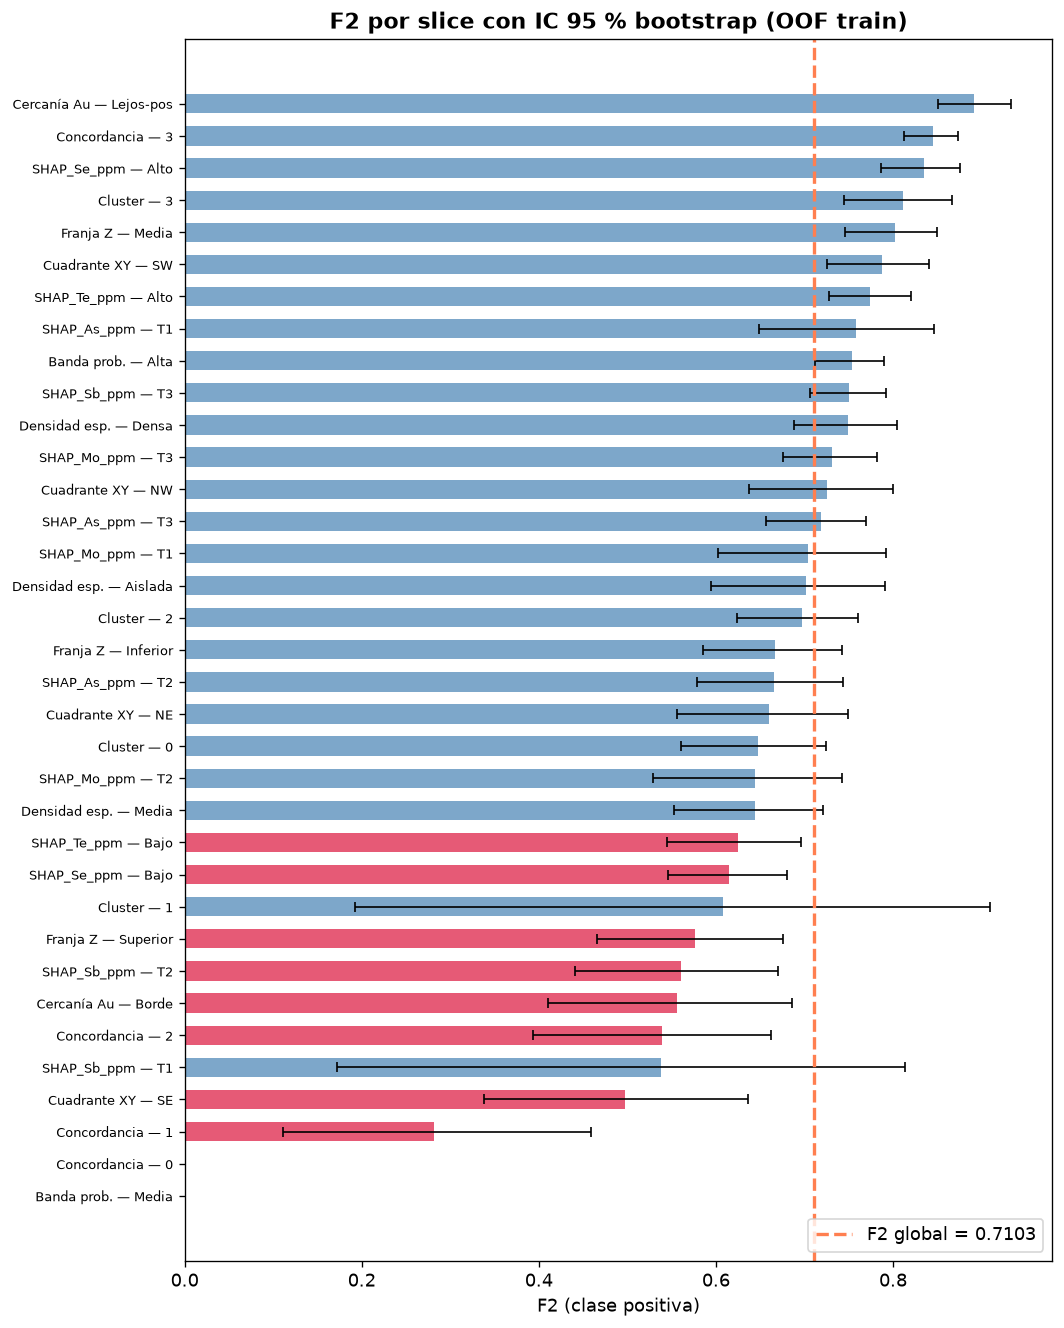

In [8]:
# ── Forest plot: F2 por slice con IC 95 % ──
plot_df = slices_df[slices_df['elegible']].copy()
plot_df = plot_df.sort_values('f2', ascending=True).reset_index(drop=True)
plot_df['label'] = plot_df['slice'] + ' — ' + plot_df['categoria'].astype(str)

fig, ax = plt.subplots(figsize=(9, max(5, len(plot_df) * 0.32)))
colors = ['crimson' if row['f2_hi'] < F2_BASE else 'steelblue' for _, row in plot_df.iterrows()]
ax.barh(range(len(plot_df)), plot_df['f2'], color=colors, alpha=0.7, height=0.6)
ax.errorbar(plot_df['f2'], range(len(plot_df)),
            xerr=[plot_df['f2'] - plot_df['f2_lo'], plot_df['f2_hi'] - plot_df['f2']],
            fmt='none', ecolor='black', capsize=3, lw=1)
ax.axvline(F2_BASE, ls='--', color='coral', lw=2, label=f'F2 global = {F2_BASE:.4f}')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=8)
ax.set_xlabel('F2 (clase positiva)')
ax.set_title('F2 por slice con IC 95 % bootstrap (OOF train)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/forest_plot_slices.png', bbox_inches='tight')
plt.show()

## Fase A - Estrategia de mitigación candidatas

En la **Fase A** se evalúan cuatro estrategias de mitigación de forma **independiente**, todas contra el mismo baseline (campeón S3, OOF) y con idéntico criterio de aceptación:

| Estrategia | Descripción |
|---|---|
| **A1 — Stacking** | Meta-modelo LogReg sobre las probabilidades OOF de los tres modelos del top-3, con verificación previa de diversidad (correlación de residuos OOF < 0.7). |
| **A2 — Re-inclusión de features** | Grid de tamaños k (del set seleccionado al set completo) re-incluyendo features en orden de importancia SHAP. |
| **A3 — Umbral por slice** | Umbral de decisión diferenciado por categoría de un slice **espacial o litológico** (cuadrante XY, franja Z, cluster). La banda de probabilidad no se usa como slice accionable para umbral porque es endógena al modelo y circularmente optimista. |
| **A4 — Ensemble de semillas** | Promedio de probabilidades sobre 10–15 seeds del campeón, reduciendo varianza estocástica. |

**Criterio de aceptación** (idéntico para las cuatro): la mejora ΔF2 sobre el baseline debe ser positiva y estadísticamente significativa según un **bootstrap pareado** (2 000 réplicas): se acepta si p_boot < 0.05.

### A1 - Stacking (meta-modelo LogReg sobre OOF del top-3)

In [9]:
# ── Diversidad del top-3: correlación de residuos OOF ──
residuos = {}
for m in TOP_3:
    residuos[m] = np.abs(y_train.values - np.array(oof_raw[m]))

corr_res = pd.DataFrame(np.corrcoef([residuos[m] for m in TOP_3]),
                         index=TOP_3, columns=TOP_3)
print('Correlación de residuos OOF entre modelos del top-3:')
display(corr_res.round(4))

pares_bajo_07 = []
for i in range(len(TOP_3)):
    for j in range(i+1, len(TOP_3)):
        r = corr_res.iloc[i, j]
        if r < 0.7:
            pares_bajo_07.append((TOP_3[i], TOP_3[j], round(r, 4)))

if pares_bajo_07:
    print(f'\n✓ {len(pares_bajo_07)} par(es) con correlación < 0.7 → hay diversidad para stacking.')
    for a, b, r in pares_bajo_07:
        print(f'  {a} vs {b}: r = {r}')
else:
    print('\n⚠ Todos los pares con correlación ≥ 0.7 → modelos redundantes; stacking puede no aportar.')

Correlación de residuos OOF entre modelos del top-3:


,XGBoost,Random Forest,SVM (RBF)
XGBoost,1.0000,0.9437,0.8603
Random Forest,0.9437,1.0000,0.8751
SVM (RBF),0.8603,0.8751,1.0000



⚠ Todos los pares con correlación ≥ 0.7 → modelos redundantes; stacking puede no aportar.


In [10]:
# ── A1: Stacking con CV anidado ──
t0 = time.time()

scaler_meta = StandardScaler()
X_meta = scaler_meta.fit_transform(OOF_MATRIX.values)

# OOF del meta-modelo (CV anidado sobre las OOF de S3)
oof_stack = np.zeros(len(y_train))
for tr_idx, va_idx in CV5.split(X_meta, y_train):
    lr = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
    lr.fit(X_meta[tr_idx], y_train.iloc[tr_idx])
    oof_stack[va_idx] = lr.predict_proba(X_meta[va_idx])[:, 1]

# Umbral fijo UMBRAL_S3 (comparación honesta y homogénea con el baseline)
umbral_A1 = UMBRAL_S3
y_pred_A1 = (oof_stack >= umbral_A1).astype(int)
f2_A1 = f2_score(y_train, y_pred_A1)

# Referencia: promedio simple de las 3 OOF (mismo umbral fijo)
oof_avg = OOF_MATRIX.values.mean(axis=1)
umb_avg = UMBRAL_S3
f2_avg = f2_score(y_train, (oof_avg >= umb_avg).astype(int))

# Meta-modelo final (todo el train) y coeficientes
meta_model = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
meta_model.fit(X_meta, y_train)
coefs_A1 = {m: round(float(c), 4) for m, c in zip(TOP_3, meta_model.coef_[0])}

# Bootstrap pareado vs baseline
dA1, loA1, hiA1, pA1 = bootstrap_delta_f2(y_train, y_pred_base, y_pred_A1)

elapsed = time.time() - t0
print(f'A1 Stacking: F2_OOF = {f2_A1:.4f} (umbral = {umbral_A1:.4f}) [{elapsed:.1f}s]')
print(f'   Promedio simple (referencia): F2_OOF = {f2_avg:.4f}')
print(f'   Coeficientes LogReg: {coefs_A1}')
print(f'   ΔF2 vs baseline = {dA1:+.4f}  IC 95 % [{loA1:+.4f}, {hiA1:+.4f}]  p_boot = {pA1:.4f}')

A1 Stacking: F2_OOF = 0.6927 (umbral = 0.1633) [7.6s]
   Promedio simple (referencia): F2_OOF = 0.6993
   Coeficientes LogReg: {'XGBoost': 0.9768, 'Random Forest': 0.304, 'SVM (RBF)': 0.3907}
   ΔF2 vs baseline = -0.0176  IC 95 % [-0.0564, +0.0180]  p_boot = 0.8185


### A2 - Re-inclusión de features

In [11]:
# ── A2: re-inclusión de features del campeón ──
t0 = time.time()
cfg_c = TOP3_CONFIG[CAMPEON_S3]
set_c = cfg_c['set']
bal_c = cfg_c['balanceo']
Xtr_c_full = SETS_TR[set_c]
params_c = RESUMEN_S3['optuna_s3'][CAMPEON_S3]['params']

# Ranking SHAP completo del campeón
ranking_shap = [f for f in shap_imp['feature'].tolist() if f in Xtr_c_full.columns]
n_sel = len(FEATURES_S3[CAMPEON_S3])
n_full = len(ranking_shap)

# Grid
K_GRID = sorted(set([n_sel] + [k for k in [n_sel + 3, n_sel + 5, n_sel + 8, n_sel + 12, n_full]
                     if n_sel < k <= n_full]))
print(f'Campeón: {CAMPEON_S3} | set seleccionado = {n_sel} features | universo = {n_full}')
print(f'Grid de k: {K_GRID}\n')

res_A2 = []
oof_A2_dict = {}
for k in K_GRID:
    feats_k = ranking_shap[:k]
    oof_k = oof_proba_pipe(lambda _k=k, _f=ranking_shap[:k]: make_pipe(CAMPEON_S3, params_c, bal_c),
                           Xtr_c_full[ranking_shap[:k]], y_train)
    umb_k = UMBRAL_S3  # umbral fijo (comparación honesta con el baseline)
    f2_k = f2_score(y_train, (oof_k >= umb_k).astype(int))
    oof_A2_dict[k] = (oof_k, umb_k)
    res_A2.append({'k': k, 'f2_oof': f2_k, 'umbral': umb_k})
    print(f'  k = {k:3d} → F2_OOF = {f2_k:.4f} (umbral = {umb_k:.4f})')

df_A2 = pd.DataFrame(res_A2)
df_A2.to_csv(f'{DIR_TAB}/a2_reinclusion.csv', index=False)

# Mejor k del grid
k_A2 = int(df_A2.loc[df_A2['f2_oof'].idxmax(), 'k'])
oof_A2, umbral_A2 = oof_A2_dict[k_A2]
y_pred_A2 = (oof_A2 >= umbral_A2).astype(int)
f2_A2 = f2_score(y_train, y_pred_A2)

# Bootstrap pareado
dA2, loA2, hiA2, pA2 = bootstrap_delta_f2(y_train, y_pred_base, y_pred_A2)

elapsed = time.time() - t0
print(f'\nA2 Re-inclusión: mejor k = {k_A2} → F2_OOF = {f2_A2:.4f} [{elapsed:.0f}s]')
print(f'   ΔF2 vs baseline = {dA2:+.4f}  IC 95 % [{loA2:+.4f}, {hiA2:+.4f}]  p_boot = {pA2:.4f}')

Campeón: XGBoost | set seleccionado = 28 features | universo = 45
Grid de k: [28, 31, 33, 36, 40, 45]

  k =  28 → F2_OOF = 0.6787 (umbral = 0.1633)
  k =  31 → F2_OOF = 0.6794 (umbral = 0.1633)
  k =  33 → F2_OOF = 0.6776 (umbral = 0.1633)
  k =  36 → F2_OOF = 0.6679 (umbral = 0.1633)
  k =  40 → F2_OOF = 0.6727 (umbral = 0.1633)
  k =  45 → F2_OOF = 0.6761 (umbral = 0.1633)

A2 Re-inclusión: mejor k = 31 → F2_OOF = 0.6794 [25s]
   ΔF2 vs baseline = -0.0309  IC 95 % [-0.0555, -0.0032]  p_boot = 0.9885


### A3 - Umbral diferenciado por slice

In [12]:
# ── A3: umbral por slice (solo slices espaciales/litológicos) ──
t0 = time.time()

def _opt_umbrales_slice(slice_cats, p, y_true, umbral_global):
    """Umbral F2-óptimo por categoría (ajuste sobre el conjunto dado)."""
    umbrales = {}
    sc = np.asarray(slice_cats).astype(str)
    yv = np.asarray(y_true)
    for cat in pd.unique(sc):
        mask = (sc == cat)
        if mask.sum() < 20 or yv[mask].sum() < MIN_POS:
            umbrales[str(cat)] = float(umbral_global)
            continue
        best_thr = umbral_global
        best_f2 = f2_score(yv[mask], (p[mask] >= umbral_global).astype(int))
        for thr in np.arange(0.05, 0.90, 0.01):
            f2_loc = f2_score(yv[mask], (p[mask] >= thr).astype(int))
            if f2_loc > best_f2:
                best_f2, best_thr = f2_loc, thr
        umbrales[str(cat)] = float(best_thr)
    return umbrales

def umbral_por_slice_f2(slice_cats, p_oof, y_true, umbral_global):
    """(Ajuste in-sample) Devuelve (predicciones, dict de umbrales) sobre TODO el train.
    Se usa para MATERIALIZAR umbrales; la ACEPTACIÓN estadística usa la versión nested."""
    umbs = _opt_umbrales_slice(slice_cats, p_oof, y_true, umbral_global)
    sc = np.asarray(slice_cats).astype(str)
    y_pred = (p_oof >= umbral_global).astype(int).copy()
    for cat, thr in umbs.items():
        m = (sc == cat)
        if m.any():
            y_pred[m] = (p_oof[m] >= thr).astype(int)
    return y_pred, umbs

def umbral_por_slice_f2_nested(slice_cats, p_oof, y_true, umbral_global, cv=CV5):
    """OOF HONESTO: en cada fold se ajustan los umbrales por slice SOLO con el train
    interno y se aplican al fold de validación. Evita el optimismo del ajuste in-sample
    (que era la causa del salto F2_OOF→hold-out)."""
    sc = np.asarray(slice_cats).astype(str)
    yv = np.asarray(y_true)
    y_pred = (p_oof >= umbral_global).astype(int).copy()
    for tr_idx, va_idx in cv.split(p_oof.reshape(-1, 1), yv):
        umbs_tr = _opt_umbrales_slice(sc[tr_idx], p_oof[tr_idx], yv[tr_idx], umbral_global)
        for cat, thr in umbs_tr.items():
            m = (sc[va_idx] == cat)
            if m.any():
                idx = va_idx[m]
                y_pred[idx] = (p_oof[idx] >= thr).astype(int)
    return y_pred

# Candidatos A3: solo espaciales/litológicos (NO banda de probabilidad)
CANDIDATOS_A3 = {
    'Cuadrante XY': pd.Series(slice_cuadrante),
    'Franja Z': pd.Series(slice_z),
    'Cluster': pd.Series(cluster_train),
}

res_A3 = []
preds_A3 = {}
for nombre, cats in CANDIDATOS_A3.items():
    # Aceptación: OOF NESTED (honesto). Materialización: umbrales in-sample (para hold-out).
    y_p = umbral_por_slice_f2_nested(cats, p_oof_base, y_train, UMBRAL_S3)
    _, umbs = umbral_por_slice_f2(cats, p_oof_base, y_train, UMBRAL_S3)
    f2_s = f2_score(y_train, y_p)
    d, lo, hi, p = bootstrap_delta_f2(y_train, y_pred_base, y_p)
    preds_A3[nombre] = (y_p, umbs)
    res_A3.append({'slice': nombre, 'f2_oof': f2_s, 'delta': d,
                   'ci_lo': lo, 'ci_hi': hi, 'p_boot': p})
    print(f'{nombre:15s}: F2_OOF(nested) = {f2_s:.4f} | Δ = {d:+.4f} '
          f'IC 95 % [{lo:+.4f}, {hi:+.4f}] p_boot = {p:.4f}')
    print(f'{"":15s}  umbrales in-sample: { {k: round(v, 3) for k, v in umbs.items()} }')

df_A3 = pd.DataFrame(res_A3)
df_A3.to_csv(f'{DIR_TAB}/a3_umbral_slice.csv', index=False)

# Mejor candidato A3 (por delta, con OOF nested honesto)
mejor_A3 = df_A3.loc[df_A3['delta'].idxmax()]
SLICE_A3 = mejor_A3['slice']
y_pred_A3, UMBRALES_A3 = preds_A3[SLICE_A3]
f2_A3 = f2_score(y_train, y_pred_A3)
dA3, loA3, hiA3, pA3 = bootstrap_delta_f2(y_train, y_pred_base, y_pred_A3)

elapsed = time.time() - t0
print(f'\nMejor A3: slice={SLICE_A3} → F2_OOF(nested) = {f2_A3:.4f} [{elapsed:.0f}s]')
print(f'   ΔF2 vs baseline = {dA3:+.4f}  IC 95 % [{loA3:+.4f}, {hiA3:+.4f}]  p_boot = {pA3:.4f}')
print('   Nota: los umbrales por slice se optimizan por fold interno (nested) para una '
      'estimación honesta; el ajuste in-sample inflaba el F2_OOF y no generalizaba.')

Cuadrante XY   : F2_OOF(nested) = 0.7101 | Δ = -0.0002 IC 95 % [-0.0238, +0.0237] p_boot = 0.5085
                 umbrales in-sample: {'NE': 0.32, 'SE': 0.39, 'SW': 0.13, 'NW': 0.18}
Franja Z       : F2_OOF(nested) = 0.7359 | Δ = +0.0256 IC 95 % [+0.0017, +0.0490] p_boot = 0.0180
                 umbrales in-sample: {'Inferior': 0.13, 'Superior': 0.38, 'Media': 0.18}
Cluster        : F2_OOF(nested) = 0.7125 | Δ = +0.0022 IC 95 % [-0.0223, +0.0261] p_boot = 0.4125
                 umbrales in-sample: {'0': 0.13, '2': 0.19, '1': 0.21, '3': 0.22}

Mejor A3: slice=Franja Z → F2_OOF(nested) = 0.7359 [34s]
   ΔF2 vs baseline = +0.0256  IC 95 % [+0.0017, +0.0490]  p_boot = 0.0180
   Nota: los umbrales por slice se optimizan por fold interno (nested) para una estimación honesta; el ajuste in-sample inflaba el F2_OOF y no generalizaba.


### A4 - Ensemble de semillas

In [13]:
# ── A4: Ensemble de semillas ──
t0 = time.time()
N_SEEDS = 12
SEEDS_A4 = [SEED + i for i in range(N_SEEDS)]

feats_c = FEATURES_S3[CAMPEON_S3]
Xtr_c = SETS_TR[set_c][feats_c]

oof_seeds = np.zeros((len(y_train), N_SEEDS))
for si, seed_i in enumerate(SEEDS_A4):
    cv_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed_i)
    params_seed = params_c.copy()
    # No cambiar use_class_weight, solo la seed del modelo
    oof_i = np.zeros(len(y_train))
    for tr_idx, va_idx in cv_i.split(Xtr_c, y_train):
        pipe_i = make_pipe(CAMPEON_S3, params_seed, bal_c)
        # Cambiar la seed interna del clasificador
        clf_step = pipe_i.named_steps['clf']
        if hasattr(clf_step, 'random_state'):
            clf_step.random_state = seed_i
        pipe_i.fit(Xtr_c.iloc[tr_idx], y_train.iloc[tr_idx])
        oof_i[va_idx] = pipe_i.predict_proba(Xtr_c.iloc[va_idx])[:, 1]
    oof_seeds[:, si] = oof_i

oof_A4 = oof_seeds.mean(axis=1)
umbral_A4 = UMBRAL_S3  # umbral fijo (comparación honesta con el baseline)
y_pred_A4 = (oof_A4 >= umbral_A4).astype(int)
f2_A4 = f2_score(y_train, y_pred_A4)

# Bootstrap pareado
dA4, loA4, hiA4, pA4 = bootstrap_delta_f2(y_train, y_pred_base, y_pred_A4)

elapsed = time.time() - t0
print(f'A4 Ensemble de semillas ({N_SEEDS} seeds): F2_OOF = {f2_A4:.4f} (umbral = {umbral_A4:.4f}) [{elapsed:.1f}s]')
print(f'   ΔF2 vs baseline = {dA4:+.4f}  IC 95 % [{loA4:+.4f}, {hiA4:+.4f}]  p_boot = {pA4:.4f}')
print(f'   Seeds: {SEEDS_A4}')

A4 Ensemble de semillas (12 seeds): F2_OOF = 0.6797 (umbral = 0.1633) [25.8s]
   ΔF2 vs baseline = -0.0305  IC 95 % [-0.0590, +0.0013]  p_boot = 0.9705
   Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]


## Resultados de la Fase A

Fase A — baseline F2_OOF = 0.7103


,estrategia,detalle,f2_oof,delta,ci_lo,ci_hi,p_boot,aceptada
0,A3_umbral_slice,slice = Franja Z,0.735913,0.025617,0.001700,0.049025,0.0180,True
1,A1_stacking,LogReg sobre OOF top-3,0.692718,-0.017578,-0.056386,0.017962,0.8185,False
2,A4_ensemble_seeds,12 seeds,0.679748,-0.030548,-0.059044,0.001261,0.9705,False
3,A2_reinclusion,k = 31 features,0.679367,-0.030928,-0.055508,-0.003228,0.9885,False



Estrategias aceptadas (Δ > 0 y p_boot < 0.05): ['A3_umbral_slice']


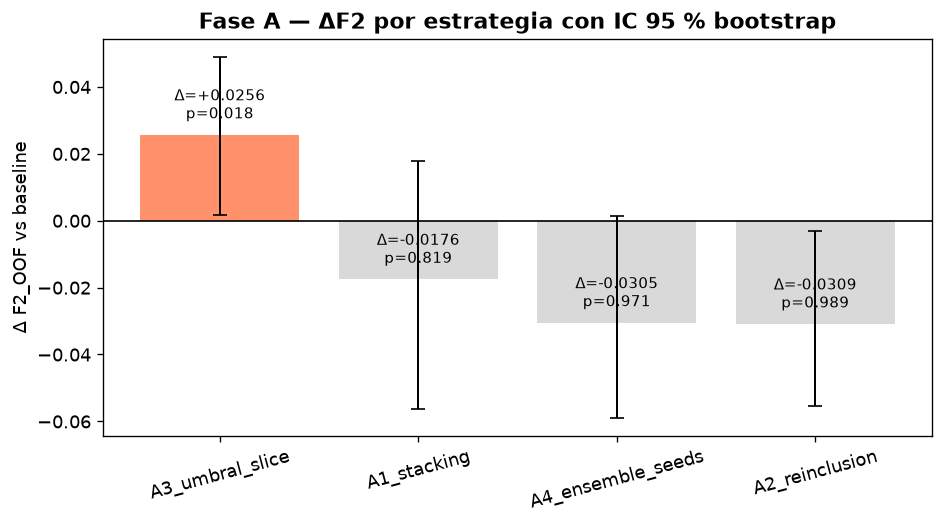

In [14]:
# ── Tabla Fase A: las 4 estrategias con el mismo criterio ──
fase_a = pd.DataFrame([
    {'estrategia': 'A1_stacking', 'detalle': f'LogReg sobre OOF top-3',
     'f2_oof': f2_A1, 'delta': dA1, 'ci_lo': loA1, 'ci_hi': hiA1, 'p_boot': pA1},
    {'estrategia': 'A2_reinclusion', 'detalle': f'k = {k_A2} features',
     'f2_oof': f2_A2, 'delta': dA2, 'ci_lo': loA2, 'ci_hi': hiA2, 'p_boot': pA2},
    {'estrategia': 'A3_umbral_slice', 'detalle': f'slice = {SLICE_A3}',
     'f2_oof': f2_A3, 'delta': dA3, 'ci_lo': loA3, 'ci_hi': hiA3, 'p_boot': pA3},
    {'estrategia': 'A4_ensemble_seeds', 'detalle': f'{N_SEEDS} seeds',
     'f2_oof': f2_A4, 'delta': dA4, 'ci_lo': loA4, 'ci_hi': hiA4, 'p_boot': pA4},
])
fase_a['aceptada'] = (fase_a['delta'] > 0) & (fase_a['p_boot'] < 0.05)
fase_a = fase_a.sort_values('delta', ascending=False).reset_index(drop=True)
fase_a.to_csv(f'{DIR_TAB}/fase_a_resultados.csv', index=False)

print(f'Fase A — baseline F2_OOF = {F2_BASE:.4f}')
display(fase_a)

aceptadas = fase_a[fase_a['aceptada']]['estrategia'].tolist()
print(f'\nEstrategias aceptadas (Δ > 0 y p_boot < 0.05): {aceptadas if aceptadas else "ninguna"}')

# Gráfico de deltas
fig, ax = plt.subplots(figsize=(8, 4.5))
colores_bar = ['coral' if a else 'lightgray' for a in fase_a['aceptada']]
ax.bar(fase_a['estrategia'], fase_a['delta'], color=colores_bar, alpha=0.85)
ax.errorbar(fase_a['estrategia'], fase_a['delta'],
            yerr=[fase_a['delta'] - fase_a['ci_lo'], fase_a['ci_hi'] - fase_a['delta']],
            fmt='none', ecolor='black', capsize=4, lw=1.2)
ax.axhline(0, color='black', lw=1)
for i, row in fase_a.iterrows():
    ax.annotate(f"Δ={row['delta']:+.4f}\np={row['p_boot']:.3f}", (i, row['delta']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_ylabel('Δ F2_OOF vs baseline')
ax.set_title('Fase A — ΔF2 por estrategia con IC 95 % bootstrap', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/fase_a_deltas.png', bbox_inches='tight')
plt.show()

## Fase B - Combinación forward incremental

En la **Fase B** las estrategias aceptadas en la Fase A se combinan de forma **forward incremental** (sin decisiones manuales):

1. Se ordenan las estrategias aceptadas por su ΔF2 (descendente).
2. Se parte de la mejor y se añade la siguiente **una a la vez**.
3. Cada adición se conserva únicamente si la combinación mejora significativamente a la combinación anterior (mismo bootstrap pareado, p < 0.05).

**Reglas de composición**: A2 redefine el set de features del campeón; A4 redefine las probabilidades OOF del campeón (ensemble de semillas); A1 combina las probabilidades de los tres modelos; A3 aplica umbrales por slice a la probabilidad final. Si ninguna estrategia fue aceptada, el modelo final es el baseline (campeón S3).

In [15]:
# ── Fase B: forward incremental ──
def construir_pred(combo, con_A2_oof=None, con_A4_oof=None):
    """Construye la predicción OOF para una combinación de estrategias.
    A3 usa umbrales por slice NESTED (honestos); el resto, umbral global UMBRAL_S3."""
    # Probabilidad base del campeón: A4 → A2 → OOF original
    if 'A4_ensemble_seeds' in combo and con_A4_oof is not None:
        p_campeon = con_A4_oof
    elif 'A2_reinclusion' in combo and con_A2_oof is not None:
        p_campeon = con_A2_oof
    else:
        p_campeon = p_oof_base

    # A1: stacking (reemplaza la columna del campeón con su prob actual)
    if 'A1_stacking' in combo:
        M = OOF_MATRIX.copy()
        M[CAMPEON_S3] = p_campeon
        sc_m = StandardScaler()
        Xm = sc_m.fit_transform(M.values)
        p_fin = np.zeros(len(y_train))
        for tr_idx, va_idx in CV5.split(Xm, y_train):
            lr = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
            lr.fit(Xm[tr_idx], y_train.iloc[tr_idx])
            p_fin[va_idx] = lr.predict_proba(Xm[va_idx])[:, 1]
    else:
        p_fin = p_campeon

    # Umbral: global fijo (UMBRAL_S3) o por slice (A3, NESTED honesto).
    if 'A3_umbral_slice' in combo:
        y_p = umbral_por_slice_f2_nested(CANDIDATOS_A3[SLICE_A3], p_fin, y_train, UMBRAL_S3)
        _, umbs = umbral_por_slice_f2(CANDIDATOS_A3[SLICE_A3], p_fin, y_train, UMBRAL_S3)
        return y_p, p_fin, umbs
    else:
        return (p_fin >= UMBRAL_S3).astype(int), p_fin, UMBRAL_S3

# Orden forward (aceptadas, por delta desc)
orden_fw = fase_a[fase_a['aceptada']].sort_values('delta', ascending=False)['estrategia'].tolist()
print(f'Orden forward: {orden_fw if orden_fw else "— (ninguna aceptada)"}\n')

historial_fb = []
if not orden_fw:
    COMBO_FINAL = []
    y_pred_combo = y_pred_base.copy()
    p_oof_combo = p_oof_base.copy()
    umbral_combo = UMBRAL_S3
    F2_COMBO = F2_BASE
    print('Ninguna estrategia aceptada → el modelo final del S4 es el baseline (campeón S3).')
else:
    oof_A2_arr = oof_A2 if 'A2_reinclusion' in orden_fw else None
    oof_A4_arr = oof_A4 if 'A4_ensemble_seeds' in orden_fw else None

    # Paso 1: mejor estrategia sola
    COMBO_FINAL = [orden_fw[0]]
    y_pred_combo, p_oof_combo, umbral_combo = construir_pred(COMBO_FINAL, oof_A2_arr, oof_A4_arr)
    F2_COMBO = f2_score(y_train, y_pred_combo)
    historial_fb.append({'paso': 1, 'combo': '+'.join(COMBO_FINAL), 'f2_oof': F2_COMBO,
                         'delta': F2_COMBO - F2_BASE, 'p_boot': 0.0, 'accion': 'añadir'})
    print(f'Paso 1: {COMBO_FINAL} → F2_OOF = {F2_COMBO:.4f}')

    # Pasos siguientes: añadir de a uno
    for step, estrategia in enumerate(orden_fw[1:], start=2):
        combo_candidato = COMBO_FINAL + [estrategia]
        y_p_cand, p_cand, umb_cand = construir_pred(combo_candidato, oof_A2_arr, oof_A4_arr)
        f2_cand = f2_score(y_train, y_p_cand)
        d, lo, hi, p_val = bootstrap_delta_f2(y_train, y_pred_combo, y_p_cand)
        acepta = d > 0 and p_val < 0.05
        historial_fb.append({'paso': step, 'combo': '+'.join(combo_candidato),
                             'f2_oof': f2_cand, 'delta': d, 'p_boot': p_val,
                             'accion': 'añadir' if acepta else 'rechazar'})
        print(f'Paso {step}: + {estrategia} → F2 = {f2_cand:.4f} | Δ = {d:+.4f} p = {p_val:.4f} '
              f'→ {"ACEPTAR" if acepta else "RECHAZAR"}')
        if acepta:
            COMBO_FINAL = combo_candidato
            y_pred_combo, p_oof_combo, umbral_combo = y_p_cand, p_cand, umb_cand
            F2_COMBO = f2_cand

df_fb = pd.DataFrame(historial_fb)
df_fb.to_csv(f'{DIR_TAB}/fase_b_forward.csv', index=False)

print(f'\nCombinación final: {COMBO_FINAL if COMBO_FINAL else ["baseline_campeon_s3"]}')
print(f'F2_OOF final = {F2_COMBO:.4f}')

Orden forward: ['A3_umbral_slice']



Paso 1: ['A3_umbral_slice'] → F2_OOF = 0.7359

Combinación final: ['A3_umbral_slice']
F2_OOF final = 0.7359


## Calibración y selección de umbral

Como la combinación final puede diferir del campeón del Sprint 3, antes de tocar el hold-out se **fija de forma honesta la política de decisión** sobre las probabilidades OOF del modelo final:

1. **Diagnóstico de calibración**: se reporta el *Brier score* OOF y la **curva de fiabilidad** (probabilidad predicha vs. frecuencia observada). Una buena calibración es requisito para que el umbral elegido sea transferible al hold-out.
2. **Umbral global con CV anidado**: el umbral F2-óptimo se estima **por fold interno** y se promedia (`THRESHOLD_FINAL`), replicando el protocolo del Sprint 3 (evita el optimismo de optimizar el umbral sobre todo el OOF).
3. **Política global vs. por slice**: solo se adopta una política de umbral **por slice** si supera a la global en el OOF *nested* con significancia estadística (**bootstrap pareado, p < 0.05**). En caso contrario se usa el **umbral global** por parsimonia y robustez.

Esta política —y no un umbral optimizado sobre todo el conjunto— es la que se aplica **una sola vez** al hold-out.

Brier OOF (modelo final)              : 0.0635
Umbral global nested (F2-óptimo)      : 0.1842 ± 0.0075
  umbrales por fold                   : [0.1805, 0.1805, 0.1805, 0.1992, 0.1805]
F2_OOF con umbral global nested       : 0.7196



Comparación de políticas de umbral (OOF nested):
  global   : F2 = 0.7196
  por slice: F2 = 0.7353 | Δ = +0.0157 IC 95 % [-0.0061, +0.0391] p_boot = 0.0830
  → Se adopta política GLOBAL: la mejora por slice NO es significativa (p_boot = 0.0830 ≥ 0.05) → umbral global más robusto.


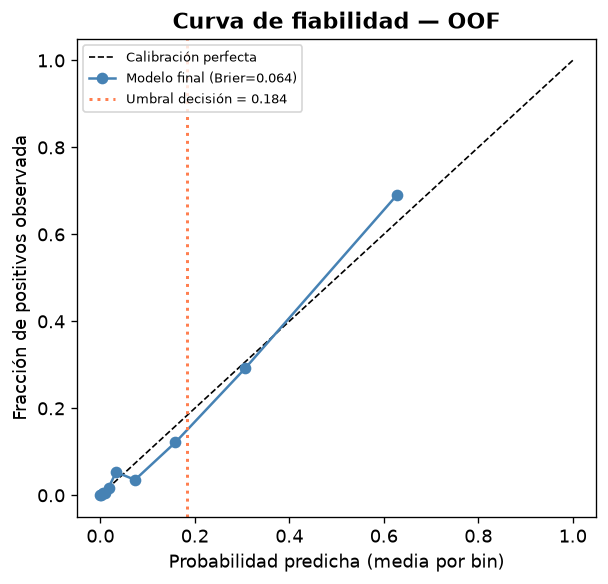

In [16]:
# ── Calibración y selección del umbral de decisión del modelo final ──
from sklearn.calibration import calibration_curve

# Probabilidades OOF del modelo final (según el combo aceptado)
p_oof_final = p_oof_base if isinstance(p_oof_combo, dict) else p_oof_combo

# 1) Diagnóstico de calibración
brier_oof = float(brier_score_loss(y_train, p_oof_final))
frac_pos, mean_pred = calibration_curve(y_train, p_oof_final, n_bins=10, strategy='quantile')

# 2) Umbral global F2-óptimo con CV anidado (promedio fold-level, estilo S3)
def umbral_global_nested(p_oof, y_true, cv=CV5):
    thrs = []
    yv = np.asarray(y_true)
    for tr_idx, _ in cv.split(p_oof.reshape(-1, 1), yv):
        thr, _ = threshold_optimo_f2(yv[tr_idx], p_oof[tr_idx])
        thrs.append(thr)
    return float(np.mean(thrs)), float(np.std(thrs)), [round(t, 4) for t in thrs]

THRESHOLD_FINAL, THR_STD, thr_folds = umbral_global_nested(p_oof_final, y_train)
y_pred_glob = (p_oof_final >= THRESHOLD_FINAL).astype(int)
F2_GLOB_OOF = f2_score(y_train, y_pred_glob)

print(f'Brier OOF (modelo final)              : {brier_oof:.4f}')
print(f'Umbral global nested (F2-óptimo)      : {THRESHOLD_FINAL:.4f} ± {THR_STD:.4f}')
print(f'  umbrales por fold                   : {thr_folds}')
print(f'F2_OOF con umbral global nested       : {F2_GLOB_OOF:.4f}')

# 3) Política global vs. por slice (solo se adopta slice si es significativamente mejor)
POLITICA_UMBRAL = 'global'
if 'A3_umbral_slice' in COMBO_FINAL:
    y_slice = umbral_por_slice_f2_nested(CANDIDATOS_A3[SLICE_A3], p_oof_final, y_train, THRESHOLD_FINAL)
    F2_SLICE_OOF = f2_score(y_train, y_slice)
    d_ps, lo_ps, hi_ps, p_ps = bootstrap_delta_f2(y_train, y_pred_glob, y_slice)
    print(f'\nComparación de políticas de umbral (OOF nested):')
    print(f'  global   : F2 = {F2_GLOB_OOF:.4f}')
    print(f'  por slice: F2 = {F2_SLICE_OOF:.4f} | Δ = {d_ps:+.4f} '
          f'IC 95 % [{lo_ps:+.4f}, {hi_ps:+.4f}] p_boot = {p_ps:.4f}')
    if d_ps > 0 and p_ps < 0.05:
        POLITICA_UMBRAL = 'slice'
        print(f'  → Se adopta política POR SLICE ({SLICE_A3}): mejora significativa.')
    else:
        print(f'  → Se adopta política GLOBAL: la mejora por slice NO es significativa '
              f'(p_boot = {p_ps:.4f} ≥ 0.05) → umbral global más robusto.')
else:
    print('\nPolítica de umbral: GLOBAL (A3 no forma parte del combo final).')

# 4) Curva de fiabilidad (calibración)
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Calibración perfecta')
ax.plot(mean_pred, frac_pos, 'o-', color='steelblue', label=f'Modelo final (Brier={brier_oof:.3f})')
ax.axvline(THRESHOLD_FINAL, color='coral', ls=':', lw=1.8,
           label=f'Umbral decisión = {THRESHOLD_FINAL:.3f}')
ax.set_xlabel('Probabilidad predicha (media por bin)')
ax.set_ylabel('Fracción de positivos observada')
ax.set_title('Curva de fiabilidad — OOF', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/calibracion_curva_fiabilidad.png', bbox_inches='tight')
plt.show()

## Evaluación en hold-out

Se materializa la combinación final sobre **todo el conjunto de entrenamiento** y se aplica **una sola vez** al hold-out. Esta evaluación es terminal: no se realizan ajustes posteriores basados en sus resultados.

Se reportan: Recall, Precision, PR-AUC, F2, F1, AUC-ROC, Brier con IC 95 %, y se contrastan contra los umbrales de la **matriz de objetivos** (Recall ≥ 0.75, F2 ≥ 0.70, AUC-ROC ≥ 0.85).

In [17]:
# ── Probabilidades de test de los 3 modelos (modelos calibrados del S3) ──
p_test = {}
for m in TOP_3:
    feats = FEATURES_S3[m]
    s = TOP3_CONFIG[m]['set']
    p_test[m] = modelos_cal[m].predict_proba(SETS_TE[s][feats])[:, 1]
    print(f'{m}: {len(feats)} features → P(+) media test = {p_test[m].mean():.4f}')

# ── A2: re-entrenar campeón con set ampliado (si está en el combo) ──
if 'A2_reinclusion' in COMBO_FINAL:
    feats_final_campeon = ranking_shap[:k_A2]
    cal_method = CONFIG_CAMPEON['calibracion'].lower()
    cal_method = 'isotonic' if 'isot' in cal_method else 'sigmoid'
    modelo_campeon_final = CalibratedClassifierCV(
        make_pipe(CAMPEON_S3, params_c, bal_c), method=cal_method, cv=5)
    modelo_campeon_final.fit(SETS_TR[set_c][feats_final_campeon], y_train)
    p_test[CAMPEON_S3] = modelo_campeon_final.predict_proba(
        SETS_TE[set_c][feats_final_campeon])[:, 1]
    print(f'\nA2 activa: campeón re-entrenado con {k_A2} features')
else:
    feats_final_campeon = FEATURES_S3[CAMPEON_S3]
    modelo_campeon_final = modelos_cal[CAMPEON_S3]

# ── A4: ensemble de semillas en test (si está en el combo) ──
if 'A4_ensemble_seeds' in COMBO_FINAL:
    p_test_seeds = np.zeros((len(y_test), N_SEEDS))
    for si, seed_i in enumerate(SEEDS_A4):
        pipe_i = make_pipe(CAMPEON_S3, params_c, bal_c)
        clf_step = pipe_i.named_steps['clf']
        if hasattr(clf_step, 'random_state'):
            clf_step.random_state = seed_i
        cal_method = CONFIG_CAMPEON['calibracion'].lower()
        cal_method = 'isotonic' if 'isot' in cal_method else 'sigmoid'
        cal_i = CalibratedClassifierCV(pipe_i, method=cal_method, cv=5)
        cal_i.fit(SETS_TR[set_c][feats_final_campeon], y_train)
        p_test_seeds[:, si] = cal_i.predict_proba(SETS_TE[set_c][feats_final_campeon])[:, 1]
    p_test[CAMPEON_S3] = p_test_seeds.mean(axis=1)
    print(f'A4 activa: ensemble de {N_SEEDS} seeds aplicado al test')

# ── A1: meta-modelo final (si está en el combo) ──
if 'A1_stacking' in COMBO_FINAL:
    M_final = OOF_MATRIX.copy()
    if 'A2_reinclusion' in COMBO_FINAL:
        M_final[CAMPEON_S3] = oof_A2
    if 'A4_ensemble_seeds' in COMBO_FINAL:
        M_final[CAMPEON_S3] = oof_A4
    scaler_final = StandardScaler()
    Xm_final = scaler_final.fit_transform(M_final.values)
    meta_final = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
    meta_final.fit(Xm_final, y_train)
    Xm_test = scaler_final.transform(pd.DataFrame(p_test)[TOP_3].values)
    p_test_final = meta_final.predict_proba(Xm_test)[:, 1]
    print('A1 activa: predicción de test con stacking')
else:
    meta_final, scaler_final = None, None
    p_test_final = p_test[CAMPEON_S3]
    print('Predicción de test con el campeón individual')

# ── Política de decisión final (ver sección «Calibración y selección del umbral») ──
if POLITICA_UMBRAL == 'slice' and 'A3_umbral_slice' in COMBO_FINAL:
    # Umbrales por slice ajustados sobre la OOF del modelo final
    _, umbrales_final = umbral_por_slice_f2(CANDIDATOS_A3[SLICE_A3], p_oof_final, y_train, THRESHOLD_FINAL)
    if SLICE_A3 == 'Cuadrante XY':
        cats_te = coords_test.apply(cuadrante, axis=1).astype(str)
    elif SLICE_A3 == 'Franja Z':
        cats_te = pd.cut(level_test, bins=cortes_z, labels=labels_z, include_lowest=True).astype(str)
    elif SLICE_A3 == 'Cluster':
        cats_te = pd.Series(cluster_test).astype(str)
    else:
        cats_te = pd.Series(['global'] * len(y_test))
    cats_te = np.asarray(cats_te)
    y_pred_ho = (p_test_final >= THRESHOLD_FINAL).astype(int)
    for cat, thr in umbrales_final.items():
        m = (cats_te == cat)
        if m.any():
            y_pred_ho[m] = (p_test_final[m] >= thr).astype(int)
    umbral_ho = umbrales_final
    print(f'Política POR SLICE ({SLICE_A3}) aplicada al hold-out.')
    print(f'  Umbrales: { {k: round(v, 3) for k, v in umbrales_final.items()} }')
else:
    umbral_ho = THRESHOLD_FINAL
    y_pred_ho = (p_test_final >= THRESHOLD_FINAL).astype(int)
    print(f'Política GLOBAL aplicada al hold-out. Umbral = {THRESHOLD_FINAL:.4f}')

XGBoost: 28 features → P(+) media test = 0.1270
Random Forest: 39 features → P(+) media test = 0.1236
SVM (RBF): 8 features → P(+) media test = 0.1228
Predicción de test con el campeón individual
Política GLOBAL aplicada al hold-out. Umbral = 0.1842


In [18]:
# ── Métricas completas del hold-out ──
metr_ho = {
    'F2': f2_score(y_test, y_pred_ho),
    'Recall': float(recall_score(y_test, y_pred_ho, zero_division=0)),
    'Precision': float(precision_score(y_test, y_pred_ho, zero_division=0)),
    'F1': float(f1_score(y_test, y_pred_ho)),
    'Accuracy': float(accuracy_score(y_test, y_pred_ho)),
    'AUC-ROC': float(roc_auc_score(y_test, p_test_final)),
    'AUC-PR': float(average_precision_score(y_test, p_test_final)),
    'Brier': float(brier_score_loss(y_test, p_test_final)),
}
F2_HOLDOUT = metr_ho['F2']
_, f2_ho_lo, f2_ho_hi = bootstrap_f2(y_test, y_pred_ho)

# Contraste contra matriz de objetivos
UMBRALES_MATRIZ = {'Recall': 0.75, 'F2': 0.70, 'AUC-ROC': 0.85}

print('══════ HOLD-OUT FINAL ══════')
for k, v in metr_ho.items():
    objetivo = UMBRALES_MATRIZ.get(k)
    if objetivo is not None:
        estado = '✓' if v >= objetivo else '✗'
        print(f'  {k:12s}: {v:.4f}  {estado} (objetivo ≥ {objetivo})')
    else:
        print(f'  {k:12s}: {v:.4f}')
print(f'  F2 IC 95 %  : [{f2_ho_lo:.4f}, {f2_ho_hi:.4f}]')

══════ HOLD-OUT FINAL ══════
  F2          : 0.7049  ✓ (objetivo ≥ 0.7)
  Recall      : 0.8269  ✓ (objetivo ≥ 0.75)
  Precision   : 0.4433
  F1          : 0.5772
  Accuracy    : 0.8525
  AUC-ROC     : 0.9258  ✓ (objetivo ≥ 0.85)
  AUC-PR      : 0.6876
  Brier       : 0.0626
  F2 IC 95 %  : [0.6081, 0.7859]


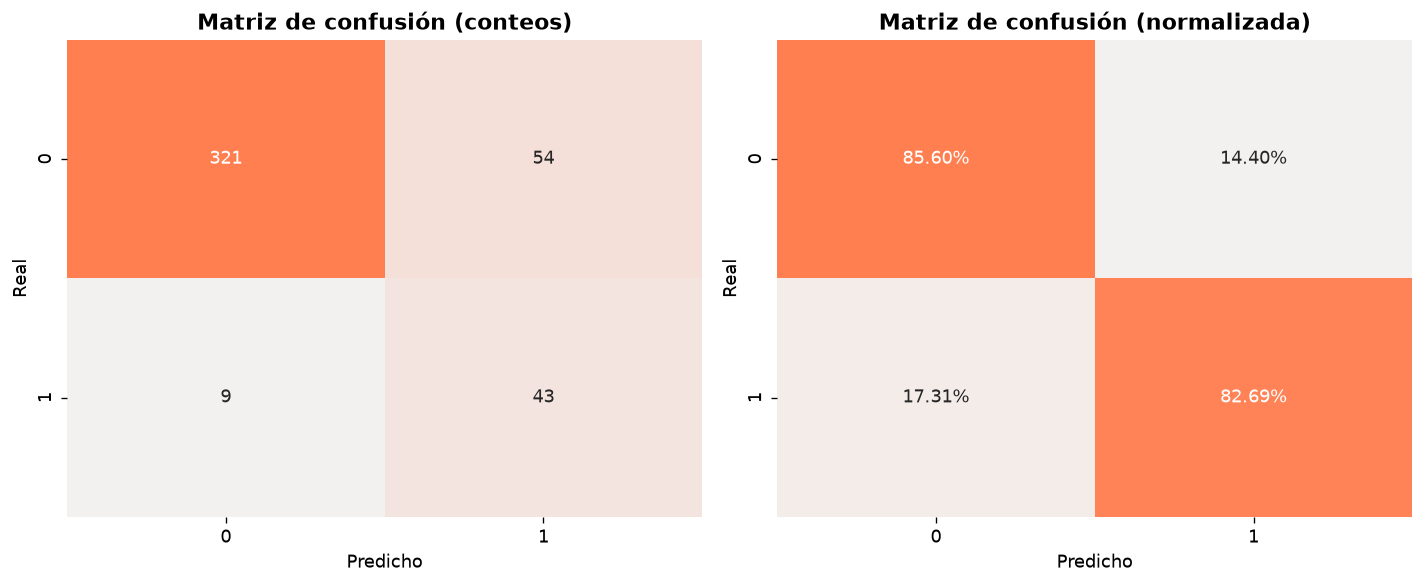

In [19]:
# ── Matrices de confusión ──
cm = confusion_matrix(y_test, y_pred_ho)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette('coral', as_cmap=True))
axes[0].set_title('Matriz de confusión (conteos)', fontweight='bold')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cbar=False, ax=axes[1],
            cmap=sns.light_palette('coral', as_cmap=True))
axes[1].set_title('Matriz de confusión (normalizada)', fontweight='bold')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/holdout_matrices_confusion.png', bbox_inches='tight')
plt.show()

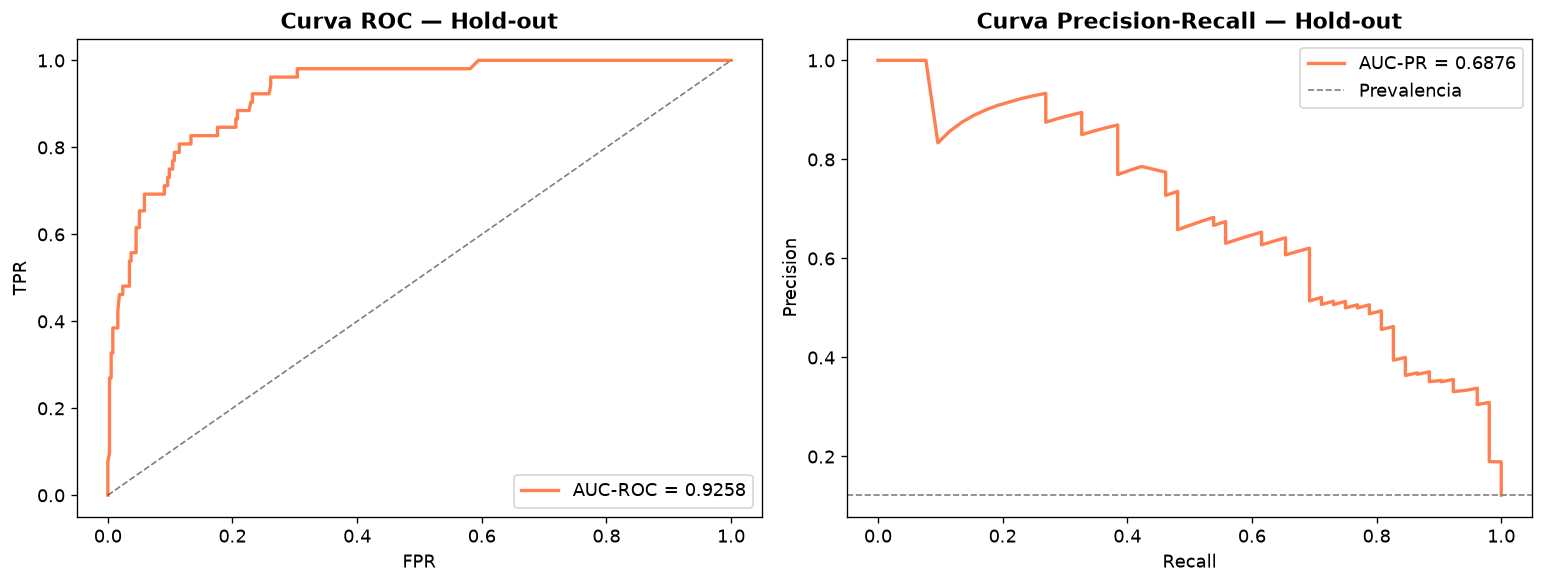

In [20]:
# ── Curvas ROC y PR ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(y_test, p_test_final)
axes[0].plot(fpr, tpr, color='coral', lw=2, label=f"AUC-ROC = {metr_ho['AUC-ROC']:.4f}")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC — Hold-out', fontweight='bold'); axes[0].legend()

prec_ho, rec_ho, _ = precision_recall_curve(y_test, p_test_final)
axes[1].plot(rec_ho, prec_ho, color='coral', lw=2, label=f"AUC-PR = {metr_ho['AUC-PR']:.4f}")
axes[1].axhline(y_test.mean(), ls='--', color='gray', lw=1, label='Prevalencia')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Hold-out', fontweight='bold'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/holdout_curvas_roc_pr.png', bbox_inches='tight')
plt.show()

In [21]:
# ── F2 por slice en hold-out (bordes de TRAIN) ──
# Reconstruir slices en test
banda_prob_te = pd.cut(p_test_final, bins=[-np.inf, EDGES_PROB[0], EDGES_PROB[1], np.inf],
                       labels=['Baja', 'Media', 'Alta'])
pred_ind_te = {}
for m in TOP_3:
    umb_m = {r['Modelo']: r['Umbral'] for r in RESUMEN_S3['top3_comparativa']}[m]
    pred_ind_te[m] = (p_test[m] >= umb_m).astype(int)
concordancia_te = sum(pred_ind_te[m] for m in TOP_3)
slice_au_te = pd.cut(au_test - 0.10, bins=EDGES_AU, labels=['Lejos-neg', 'Borde', 'Lejos-pos'])
cuad_te = coords_test.apply(cuadrante, axis=1).astype('category')
z_te = pd.cut(level_test, bins=cortes_z, labels=labels_z, include_lowest=True)
d_te, _ = tree_train.query(coords_test[['East', 'North']].values, k=11)
dens_te = pd.cut(d_te[:, 10], bins=cortes_d, labels=labels_d, include_lowest=True)
cluster_te_s = pd.Categorical(cluster_test)

# Construir slices de test (mismos que train, con bordes de TRAIN)
slices_test_list = [
    ('Banda prob.', pd.Series(banda_prob_te)),
    ('Concordancia', pd.Series(pd.Categorical(concordancia_te, categories=[0, 1, 2, 3]))),
    ('Cercanía Au', pd.Series(slice_au_te)),
    ('Cuadrante XY', pd.Series(cuad_te)),
    ('Franja Z', pd.Series(z_te)),
    ('Densidad esp.', pd.Series(dens_te)),
    ('Cluster', pd.Series(cluster_te_s)),
]

filas_te = []
for nombre, cats in slices_test_list:
    filas_te.extend(evaluar_slice(nombre, cats, y_test, y_pred_ho))
slices_test_df = pd.DataFrame(filas_te)
slices_test_df.to_csv(f'{DIR_TAB}/slices_f2_holdout.csv', index=False)

print(f'F2 hold-out global: {F2_HOLDOUT:.4f}')
print('\nF2 por slice en hold-out:')
display(slices_test_df[slices_test_df['elegible']].sort_values('f2'))

F2 hold-out global: 0.7049

F2 por slice en hold-out:


,slice,categoria,n,n_pos,f2,f2_lo,f2_hi,elegible
4,Concordancia,1,39,6,0.1708,0.0000,0.5000,True
8,Cercanía Au,Borde,31,9,0.4786,0.1471,0.7377,True
20,Cluster,0,190,14,0.5436,0.3332,0.7144,True
16,Franja Z,Superior,152,12,0.6151,0.4000,0.7778,True
14,Franja Z,Inferior,144,17,0.6219,0.4245,0.7944,True
12,Cuadrante XY,SE,107,6,0.6248,0.3331,0.8163,True
11,Cuadrante XY,NW,95,13,0.6335,0.3750,0.8333,True
17,Densidad esp.,Densa,129,26,0.6595,0.5000,0.7971,True
10,Cuadrante XY,NE,113,12,0.6706,0.4411,0.8333,True
22,Cluster,2,110,22,0.7114,0.5600,0.8333,True


## Persistencia de artefactos

In [22]:
# ── Función para sanitizar valores numpy para JSON ──
def _sanitize(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: _sanitize(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_sanitize(v) for v in obj]
    if isinstance(obj, pd.DataFrame):
        return _sanitize(obj.to_dict(orient='records'))
    return obj

# ── Guardar artefactos ──
pd.DataFrame(p_test).to_csv(f'{DIR_DATA}/probabilidades_test_top3.csv', index=False)
pd.DataFrame({'y_test': y_test.values, 'y_pred': y_pred_ho,
              'p_final': p_test_final}).to_csv(f'{DIR_DATA}/predicciones_holdout.csv', index=False)

# Modelos finales
joblib.dump(modelo_campeon_final, f'{DIR_MOD}/modelo_campeon_final.pkl')
if meta_final is not None:
    joblib.dump({'scaler': scaler_final, 'meta_model': meta_final, 'orden_modelos': TOP_3},
                f'{DIR_MOD}/meta_stacking_final.pkl')

# Config del modelo final
config_final = {
    'combo_final': COMBO_FINAL if COMBO_FINAL else ['baseline_campeon_s3'],
    'campeon_s3': CAMPEON_S3,
    'features_campeon': list(feats_final_campeon),
    'usa_stacking': 'A1_stacking' in COMBO_FINAL,
    'usa_reinclusion': 'A2_reinclusion' in COMBO_FINAL,
    'usa_umbral_slice': 'A3_umbral_slice' in COMBO_FINAL,
    'usa_ensemble_seeds': 'A4_ensemble_seeds' in COMBO_FINAL,
    'umbral': _sanitize(umbral_combo) if not isinstance(umbral_combo, dict) else None,
    'umbrales_por_slice': _sanitize(umbral_combo) if isinstance(umbral_combo, dict) else None,
    'slice_a3': SLICE_A3 if 'A3_umbral_slice' in COMBO_FINAL else None,
    'n_seeds_a4': N_SEEDS if 'A4_ensemble_seeds' in COMBO_FINAL else None,
    'seeds_a4': SEEDS_A4 if 'A4_ensemble_seeds' in COMBO_FINAL else None,
    'f2_oof': round(float(F2_COMBO), 4),
    'f2_holdout': round(float(F2_HOLDOUT), 4),
}
with open(f'{DIR_DATA}/config_final_s4.json', 'w') as f:
    json.dump(_sanitize(config_final), f, indent=2, ensure_ascii=False)

# Edges de slices (reproducibilidad)
edges_all = {
    'prob': EDGES_PROB,
    'geo': _sanitize(EDGES_GEO),
    'au': [float(e) for e in EDGES_AU if np.isfinite(e)],
    'xy': EDGES_XY,
    'z': [float(e) for e in EDGES_Z],
    'densidad': [float(e) for e in EDGES_DENS],
}
with open(f'{DIR_DATA}/edges_slices.json', 'w') as f:
    json.dump(_sanitize(edges_all), f, indent=2, ensure_ascii=False)

print(f'Artefactos guardados en {OUT}/')
for d in [DIR_DATA, DIR_MOD, DIR_FIG, DIR_TAB]:
    print(f'  {d}: {len(os.listdir(d))} archivos')

Artefactos guardados en outputs_sprint4/
  outputs_sprint4/data: 4 archivos
  outputs_sprint4/models: 1 archivos
  outputs_sprint4/figures: 7 archivos
  outputs_sprint4/tables: 6 archivos


## Mapas comparativos

Se generan dos mapas comparativos con la misma escala espacial:

1. **Isovalores de Au** — interpolación de los valores medidos de Au_ppm. Las anomalías auriferas son espacialmente cortas (restringidas al cuerpo mineralizado).
2. **Mapa de probabilidades** — interpolación de las probabilidades del modelo final. El halo geoquímico (pathfinders + alteración) se extiende más allá de la anomalía de Au, identificando zonas de interés para muestreo dirigido.

Los positivos reales (target_Au = 1) se superponen en ambos mapas para visualizar la cobertura.

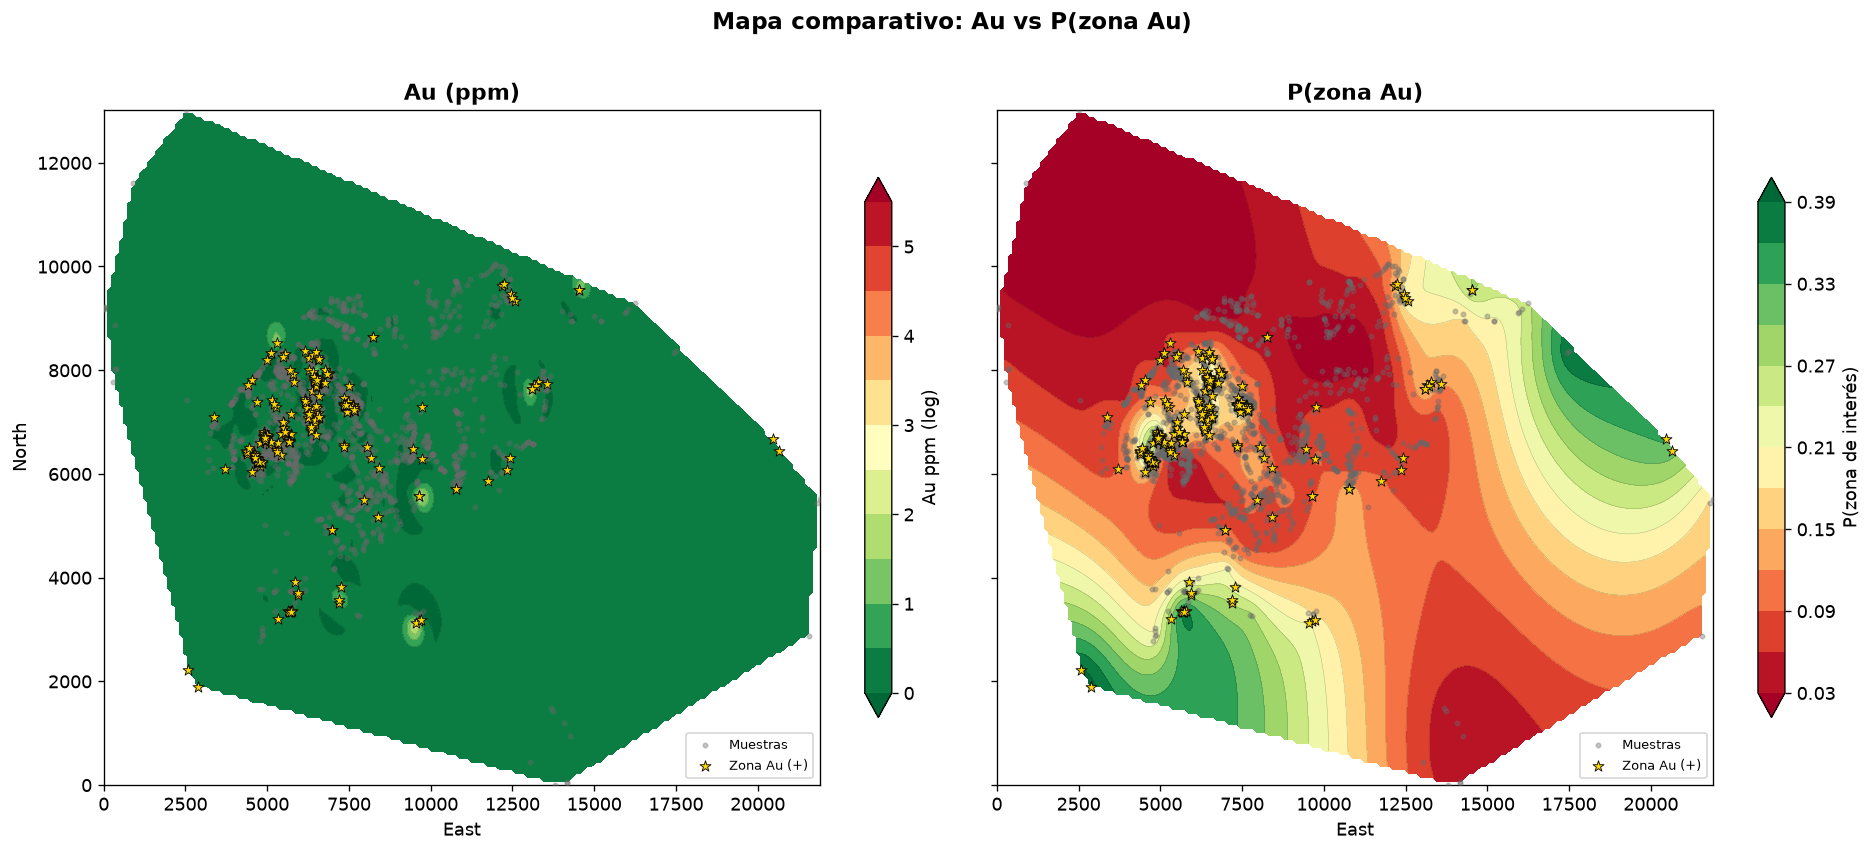

Mapas comparativos guardados (interpolación: Au=Kriging esférico, P=Kriging esférico; hull mask + scatter, 300 dpi).


In [23]:
# ── Mapas comparativos: Au vs P(zona Au) — interpolación esferoidal (kriging esférico) ──
from scipy.spatial import ConvexHull
from matplotlib.path import Path

def mascara_hull(xi, yi, puntos_xy):
    """Máscara True FUERA del convex hull de las muestras (evita extrapolar)."""
    hull = ConvexHull(puntos_xy)
    path = Path(puntos_xy[hull.vertices])
    mask = ~path.contains_points(np.column_stack([xi.ravel(), yi.ravel()]))
    return mask.reshape(xi.shape)

# Datos: train (OOF del combo) + test (p_test_final)
coords_all = pd.concat([coords_train, coords_test], ignore_index=True)
au_all = pd.concat([au_train, au_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)
p_all = np.concatenate([
    (p_oof_base if isinstance(p_oof_combo, dict) else p_oof_combo),
    p_test_final
])
east_all = coords_all['East'].values.astype(float)
north_all = coords_all['North'].values.astype(float)
puntos_xy = np.column_stack([east_all, north_all])

# Grilla
N_GRID = 180
xi = np.linspace(east_all.min(), east_all.max(), N_GRID)
yi = np.linspace(north_all.min(), north_all.max(), N_GRID)
XI, YI = np.meshgrid(xi, yi)
fuera_hull = mascara_hull(XI, YI, puntos_xy)

# Interpolación ESFEROIDAL: kriging ordinario con variograma esférico (análogo al
# interpolante esferoidal de Leapfrog Geo) → contornos curvos y suaves.
# Fallback a RBF thin-plate y luego a griddata lineal si pykrige no está disponible.
def interp_esferoidal(vals, log=False):
    v = np.log1p(vals) if log else np.asarray(vals, dtype=float)
    rng = np.random.RandomState(SEED)
    xr = east_all.max() - east_all.min()
    yr = north_all.max() - north_all.min()
    xj = east_all + rng.normal(0, xr * 1e-4, len(east_all))   # jitter anti-singularidad
    yj = north_all + rng.normal(0, yr * 1e-4, len(north_all))
    metodo = 'Kriging esférico'
    try:
        from pykrige.ok import OrdinaryKriging
        ok = OrdinaryKriging(xj, yj, v, variogram_model='spherical',
                             nlags=12, verbose=False, enable_plotting=False)
        Z, _ = ok.execute('grid', xi, yi)
        Z = np.asarray(Z, dtype=float)
    except Exception:
        try:
            from scipy.interpolate import RBFInterpolator
            Z = RBFInterpolator(np.column_stack([xj, yj]), v,
                                kernel='thin_plate_spline', smoothing=1.0)(
                np.column_stack([XI.ravel(), YI.ravel()])).reshape(XI.shape)
            metodo = 'RBF thin-plate'
        except Exception:
            Z = griddata((east_all, north_all), v, (XI, YI), method='linear')
            metodo = 'Lineal'
    if log:
        Z = np.expm1(Z)
    return Z, metodo

Zi_au, met_au = interp_esferoidal(au_all.values, log=True)
Zi_prob, met_pr = interp_esferoidal(p_all, log=False)
Zi_au = np.ma.array(Zi_au, mask=fuera_hull | np.isnan(Zi_au))
Zi_prob = np.ma.array(Zi_prob, mask=fuera_hull | np.isnan(Zi_prob))

# Capas de puntos
mask_pos = (y_all == 1).values

def _overlay(ax):
    ax.scatter(east_all, north_all, s=7, alpha=0.35, color='dimgray', zorder=3, label='Muestras')
    ax.scatter(east_all[mask_pos], north_all[mask_pos], s=48, marker='*', color='gold',
               edgecolors='black', linewidths=0.5, zorder=5, label='Zona Au (+)')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Mapa 1: Au (ppm, log)
c1 = axes[0].contourf(XI, YI, Zi_au, levels=14, cmap='RdYlGn_r', extend='both')
axes[0].contour(XI, YI, Zi_au, levels=14, colors='k', linewidths=0.25, alpha=0.35)
_overlay(axes[0])
axes[0].set_title('Au (ppm)', fontweight='bold')
axes[0].set_xlabel('East'); axes[0].set_ylabel('North')
axes[0].legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=axes[0], shrink=0.8, label='Au ppm (log)')

# Mapa 2: Probabilidad del modelo
c2 = axes[1].contourf(XI, YI, Zi_prob, levels=14, cmap='RdYlGn', extend='both')
axes[1].contour(XI, YI, Zi_prob, levels=14, colors='k', linewidths=0.25, alpha=0.3)
_overlay(axes[1])
axes[1].set_title('P(zona Au)', fontweight='bold')
axes[1].set_xlabel('East')
axes[1].legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=axes[1], shrink=0.8, label='P(zona de interés)')

plt.suptitle('Mapa comparativo: Au vs P(zona Au)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/mapas_comparativos_au_vs_prob.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'Mapas comparativos guardados (interpolación: Au={met_au}, P={met_pr}; hull mask + scatter, 300 dpi).')

## Resumen

In [24]:
# ── Resumen JSON ──
resumen4 = _sanitize({
    'sprint': 4,
    'nombre': 'Plan de mitigación: slices + Fase A (A1-A4) + Fase B (forward) + hold-out + mapas',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'protocolo': ('Diagnóstico por slices (embudo 3 etapas); Fase A: A1 stacking con diversidad, '
                  'A2 re-inclusión, A3 umbral por slice (espacial/litológico), A4 ensemble de semillas; '
                  'aceptación por bootstrap pareado (p<0.05); Fase B: forward incremental; '
                  'calibración + umbral global nested (política robusta); hold-out una sola vez con IC 95 %; mapas comparativos Au vs probabilidades (interpolación esferoidal / kriging esférico).'),
    'metrica_decision': 'f2',
    'baseline': {'modelo': CAMPEON_S3, 'f2_oof': round(F2_BASE, 4), 'umbral': round(UMBRAL_S3, 4)},
    'combo_final': COMBO_FINAL if COMBO_FINAL else ['baseline_campeon_s3'],
    'calibracion_umbral': {
        'brier_oof': round(brier_oof, 4),
        'umbral_global_nested': round(THRESHOLD_FINAL, 4),
        'umbral_global_std': round(THR_STD, 4),
        'politica_umbral': POLITICA_UMBRAL,
        'f2_oof_umbral_global': round(F2_GLOB_OOF, 4),
        'umbral_aplicado_holdout': _sanitize(umbral_ho),
    },
    'f2_oof_final': round(float(F2_COMBO), 4),
    'f2_holdout': round(float(F2_HOLDOUT), 4),
    'f2_holdout_ci95': [round(f2_ho_lo, 4), round(f2_ho_hi, 4)],
    'metricas_holdout': {k: round(v, 4) for k, v in metr_ho.items()},
    'contraste_matriz_objetivos': {
        k: {'valor': round(metr_ho[k], 4), 'objetivo': v, 'cumple': metr_ho[k] >= v}
        for k, v in UMBRALES_MATRIZ.items() if k in metr_ho
    },
    'fase_a': fase_a.round(4).to_dict(orient='records'),
    'fase_b': df_fb.round(4).to_dict(orient='records') if len(df_fb) > 0 else [],
    'a1_stacking': {
        'f2_oof': round(f2_A1, 4),
        'coeficientes': coefs_A1,
        'f2_promedio_simple': round(f2_avg, 4),
        'diversidad_residuos': corr_res.round(4).to_dict(),
        'pares_diversidad_ok': pares_bajo_07,
    },
    'a2_reinclusion': {
        'mejor_k': k_A2,
        'n_seleccion_s3': n_sel,
        'grid': K_GRID,
        'f2_oof': round(f2_A2, 4),
    },
    'a3_umbral_slice': {
        'mejor_slice': SLICE_A3,
        'f2_oof': round(f2_A3, 4),
        'candidatos': df_A3.round(4).to_dict(orient='records'),
        'nota': 'Umbrales por slice estimados con CV anidado (honesto); banda de probabilidad excluida (endógena).',
    },
    'a4_ensemble_seeds': {
        'n_seeds': N_SEEDS,
        'seeds': SEEDS_A4,
        'f2_oof': round(f2_A4, 4),
    },
    'slices_embudo': {
        'n_elegibles': n_etapa1,
        'n_etapa2_ic95': n_etapa2,
        'n_etapa3_bonferroni': n_etapa3,
        'problematicos': problematicos[['slice', 'categoria', 'f2']].to_dict(orient='records')
                         if len(problematicos) > 0 else [],
    },
    'evolucion_f2': {
        'S0': RESUMEN_S0['f2_final'],
        'S1': RESUMEN_S1['f2_final'],
        'S2': RESUMEN_S2['f2_cv_final'],
        'S3': F2_CV_S3,
        'S4': round(float(F2_COMBO), 4),
    },
    'versiones_librerias': versiones,
    'rutas': {'data': DIR_DATA, 'models': DIR_MOD, 'figures': DIR_FIG, 'tables': DIR_TAB},
})

with open(f'{OUT}/resumen_sprint4.json', 'w') as f:
    json.dump(resumen4, f, indent=2, ensure_ascii=False)
print('Resumen guardado en', f'{OUT}/resumen_sprint4.json')
print(json.dumps(resumen4, indent=2, ensure_ascii=False)[:3000])

Resumen guardado en outputs_sprint4/resumen_sprint4.json
{
  "sprint": 4,
  "nombre": "Plan de mitigación: slices + Fase A (A1-A4) + Fase B (forward) + hold-out + mapas",
  "fecha": "2026-07-31 20:46",
  "protocolo": "Diagnóstico por slices (embudo 3 etapas); Fase A: A1 stacking con diversidad, A2 re-inclusión, A3 umbral por slice (espacial/litológico), A4 ensemble de semillas; aceptación por bootstrap pareado (p<0.05); Fase B: forward incremental; calibración + umbral global nested (política robusta); hold-out una sola vez con IC 95 %; mapas comparativos Au vs probabilidades (interpolación esferoidal / kriging esférico).",
  "metrica_decision": "f2",
  "baseline": {
    "modelo": "XGBoost",
    "f2_oof": 0.7103,
    "umbral": 0.1633
  },
  "combo_final": [
    "A3_umbral_slice"
  ],
  "calibracion_umbral": {
    "brier_oof": 0.0635,
    "umbral_global_nested": 0.1842,
    "umbral_global_std": 0.0075,
    "politica_umbral": "global",
    "f2_oof_umbral_global": 0.7196,
    "umbral_apli

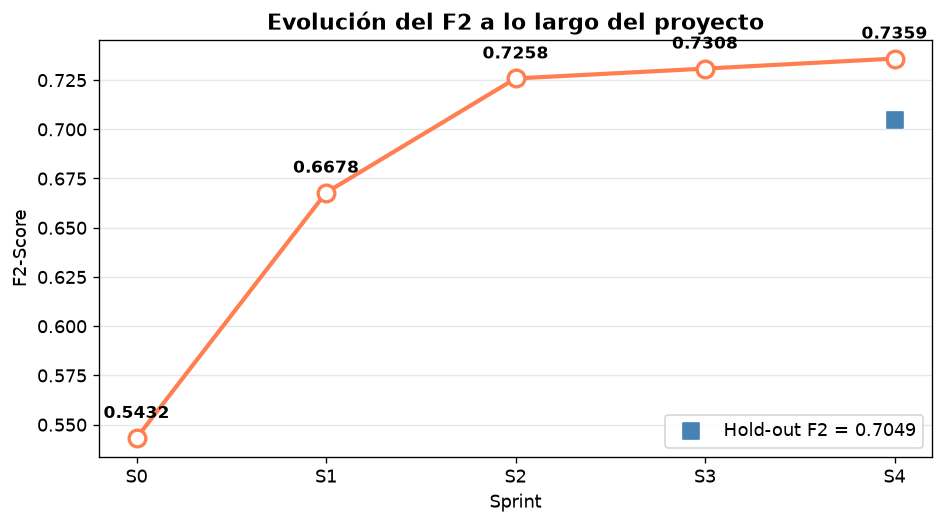

Sprint 4 completado.


In [25]:
# ── Gráfico de evolución del proyecto ──
evo = resumen4['evolucion_f2']
sprints = list(evo.keys())
f2_vals = list(evo.values())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sprints, f2_vals, marker='o', markersize=10, lw=2.5, color='coral',
        markerfacecolor='white', markeredgecolor='coral', markeredgewidth=2)
for i, (s, v) in enumerate(zip(sprints, f2_vals)):
    ax.annotate(f'{v:.4f}', (i, v), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')

# Marca del hold-out
ax.scatter([sprints[-1]], [F2_HOLDOUT], marker='s', s=100, color='steelblue',
           zorder=5, label=f'Hold-out F2 = {F2_HOLDOUT:.4f}')

ax.set_xlabel('Sprint')
ax.set_ylabel('F2-Score')
ax.set_title('Evolución del F2 a lo largo del proyecto', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/evolucion_f2_proyecto.png', bbox_inches='tight')
plt.show()

print('Sprint 4 completado.')